In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x_grid = np.linspace(-10, 0, 1000)
func_grid = x_grid + (x_grid**2) * np.sin(x_grid) / 10
eps = 1e-3
L = 13  # Максимальное количество итераций

Константа Липшица L = 8.65601991

РЕЗУЛЬТАТ
Константа Липшица L = 8.6560199058
Минимум x = -8.2305473965
f(x)      = -14.5300911005
Итераций  = 30


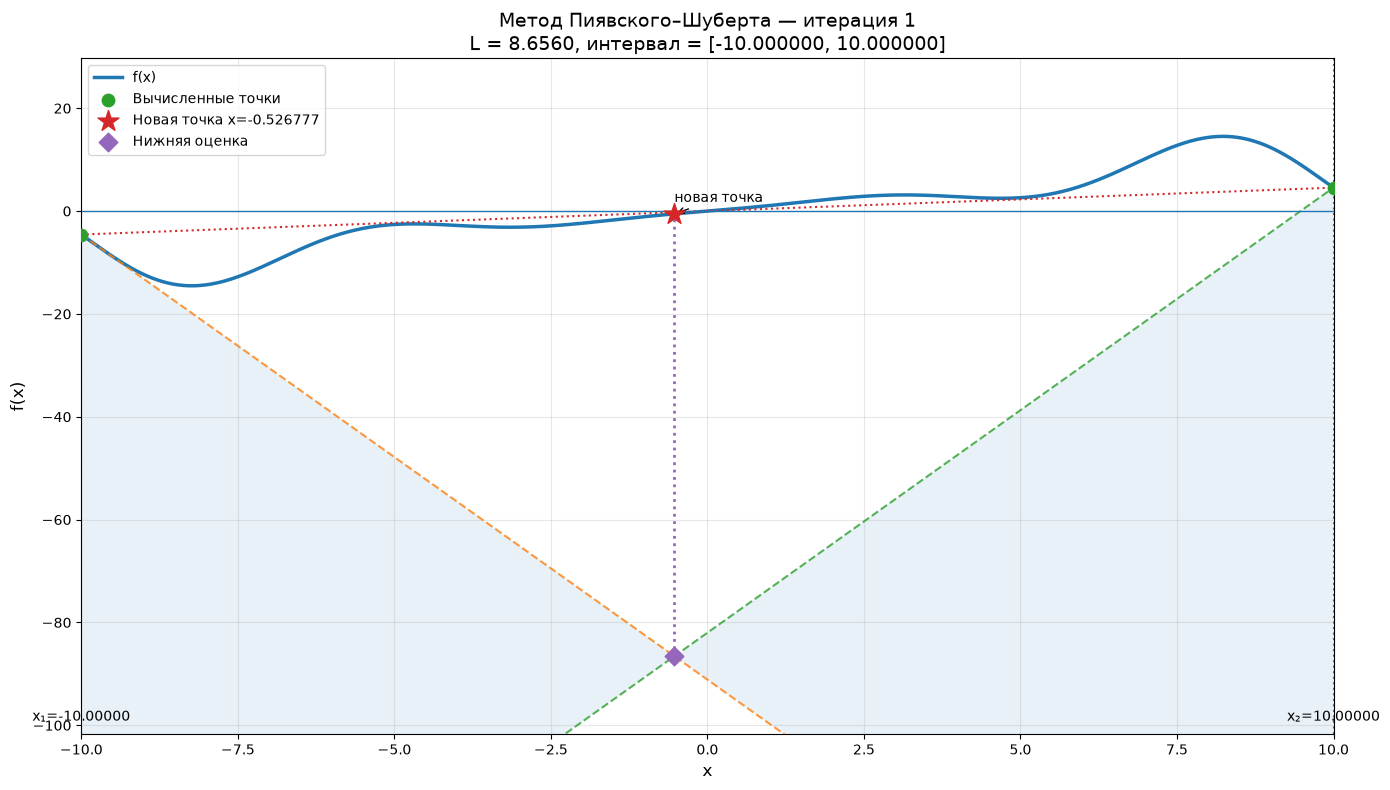

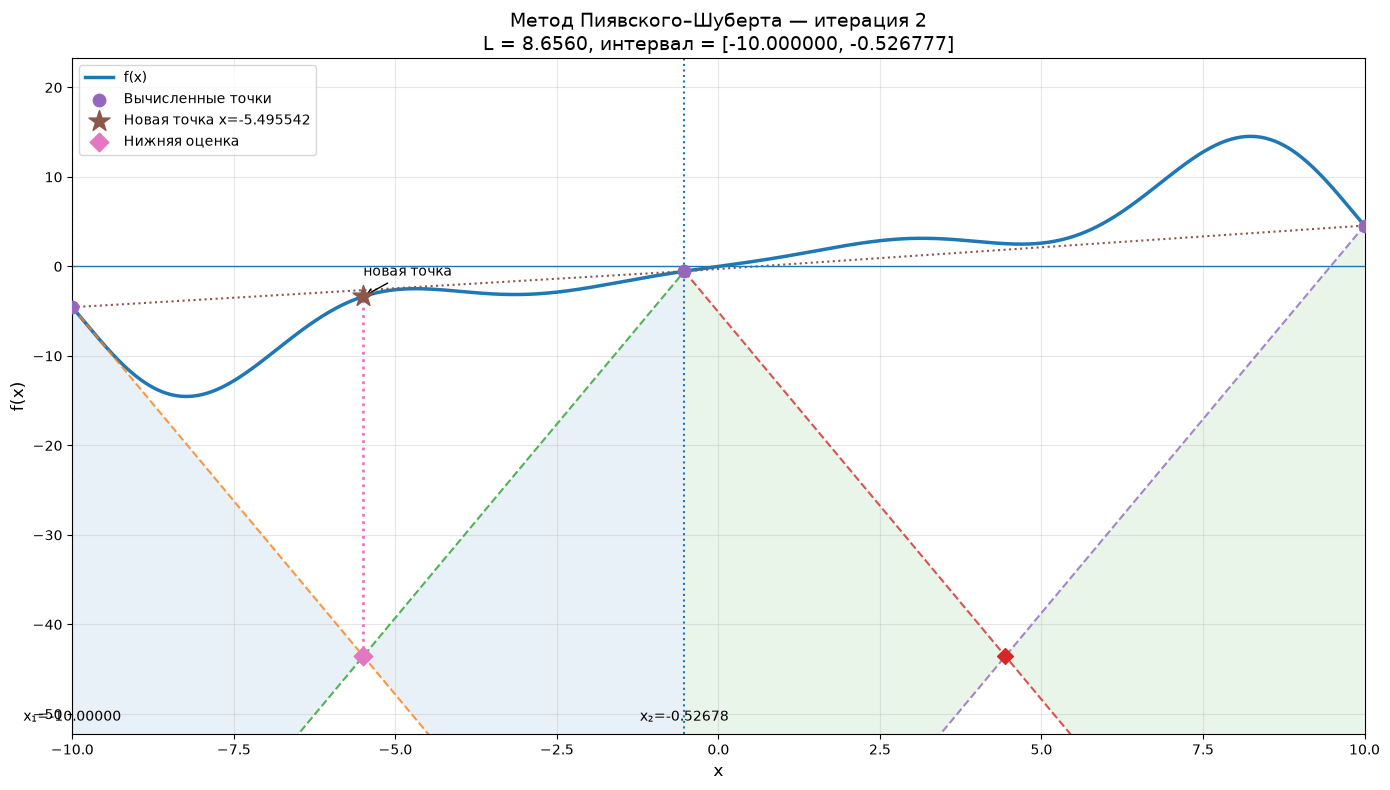

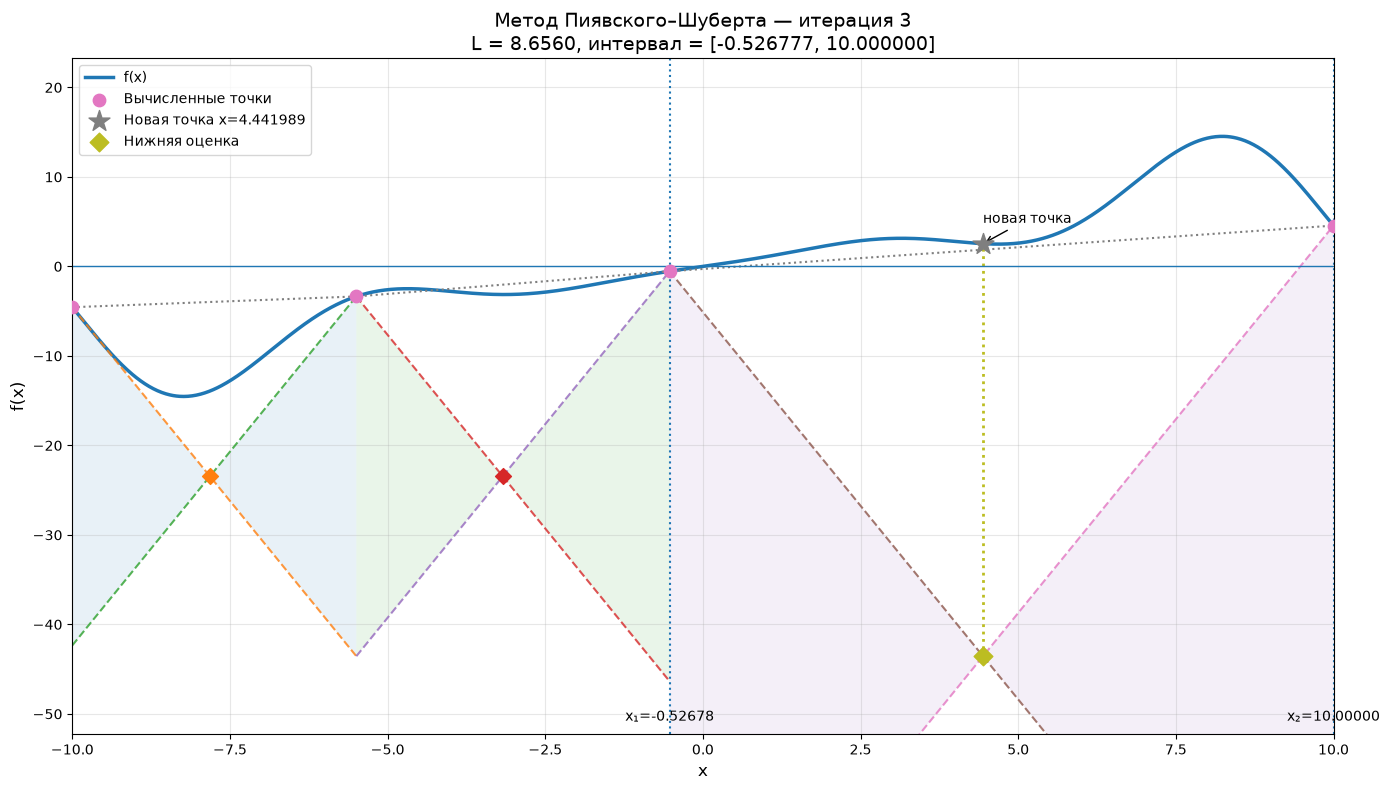

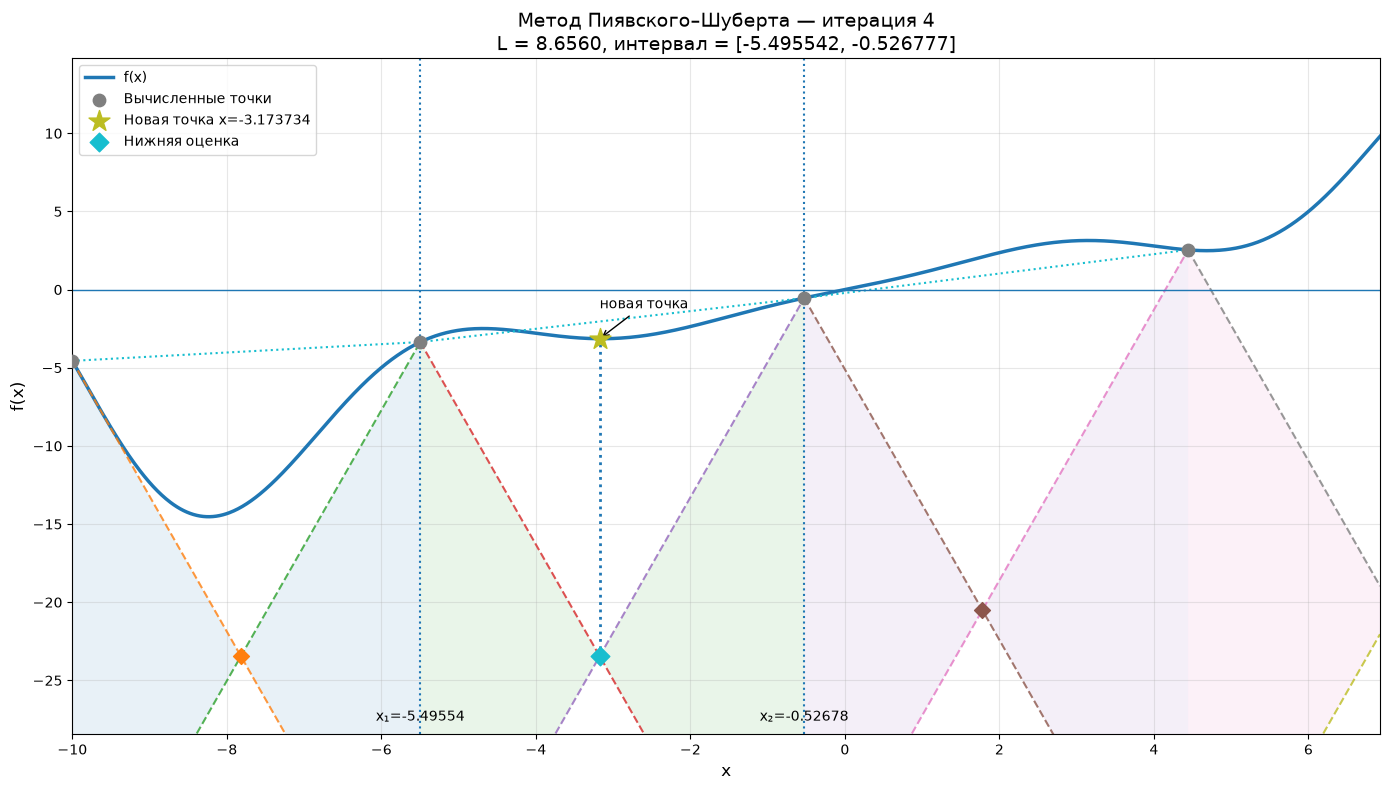

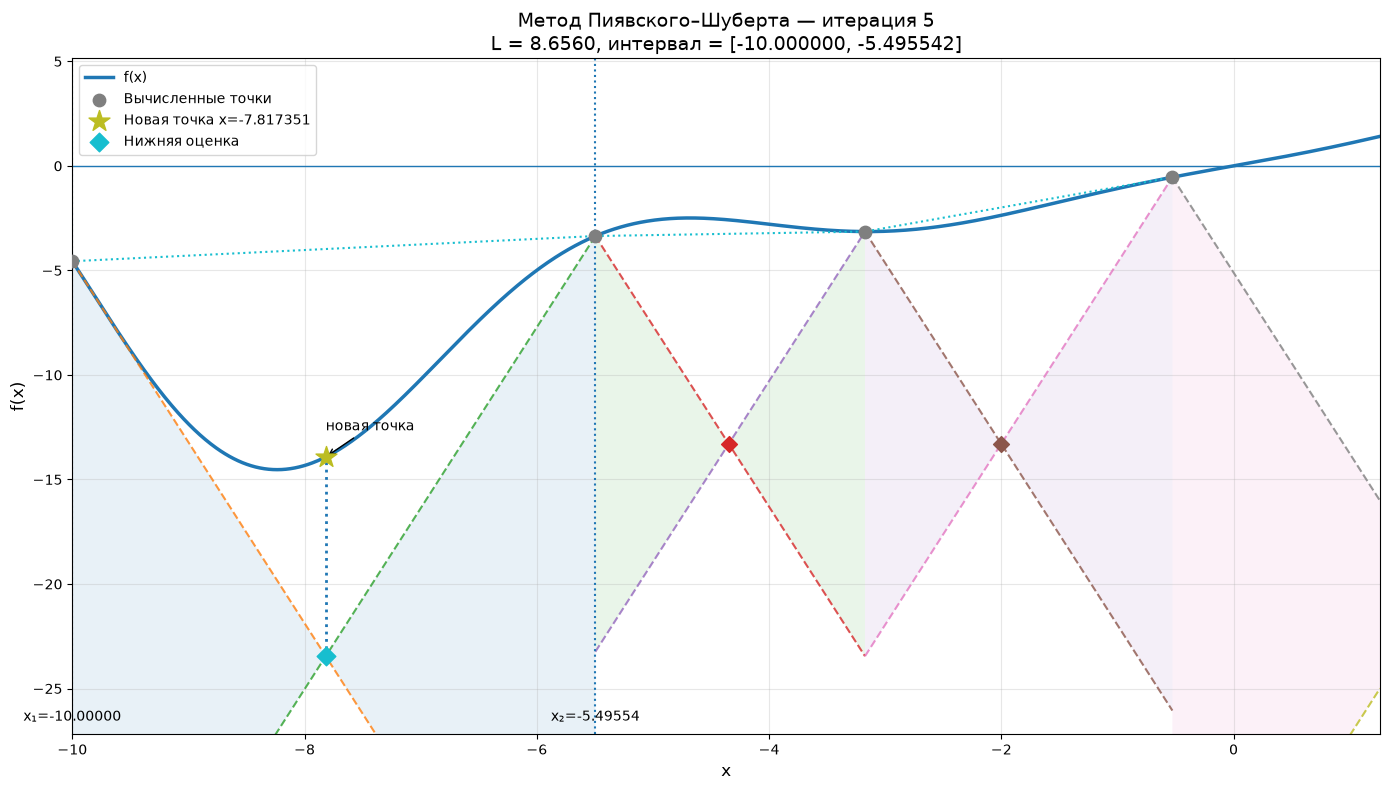

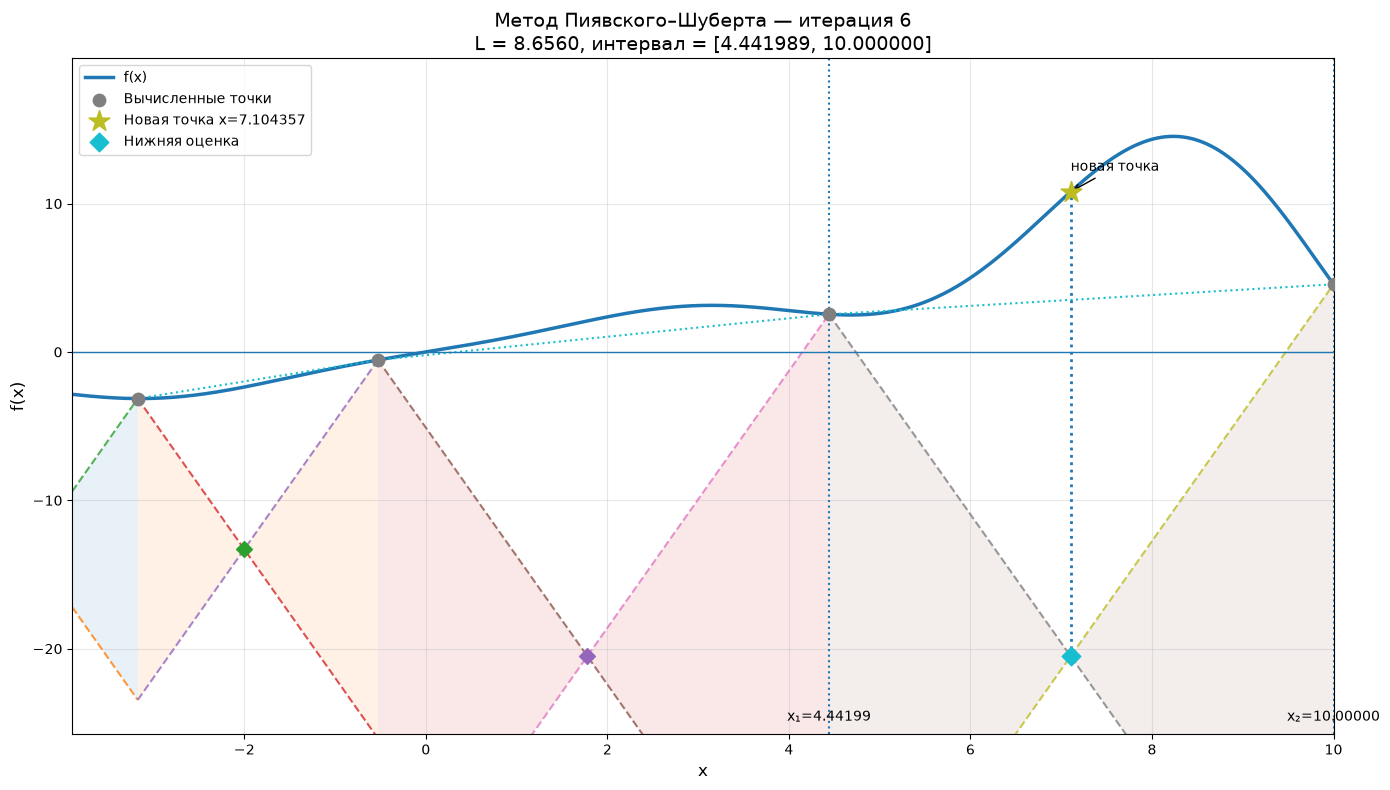

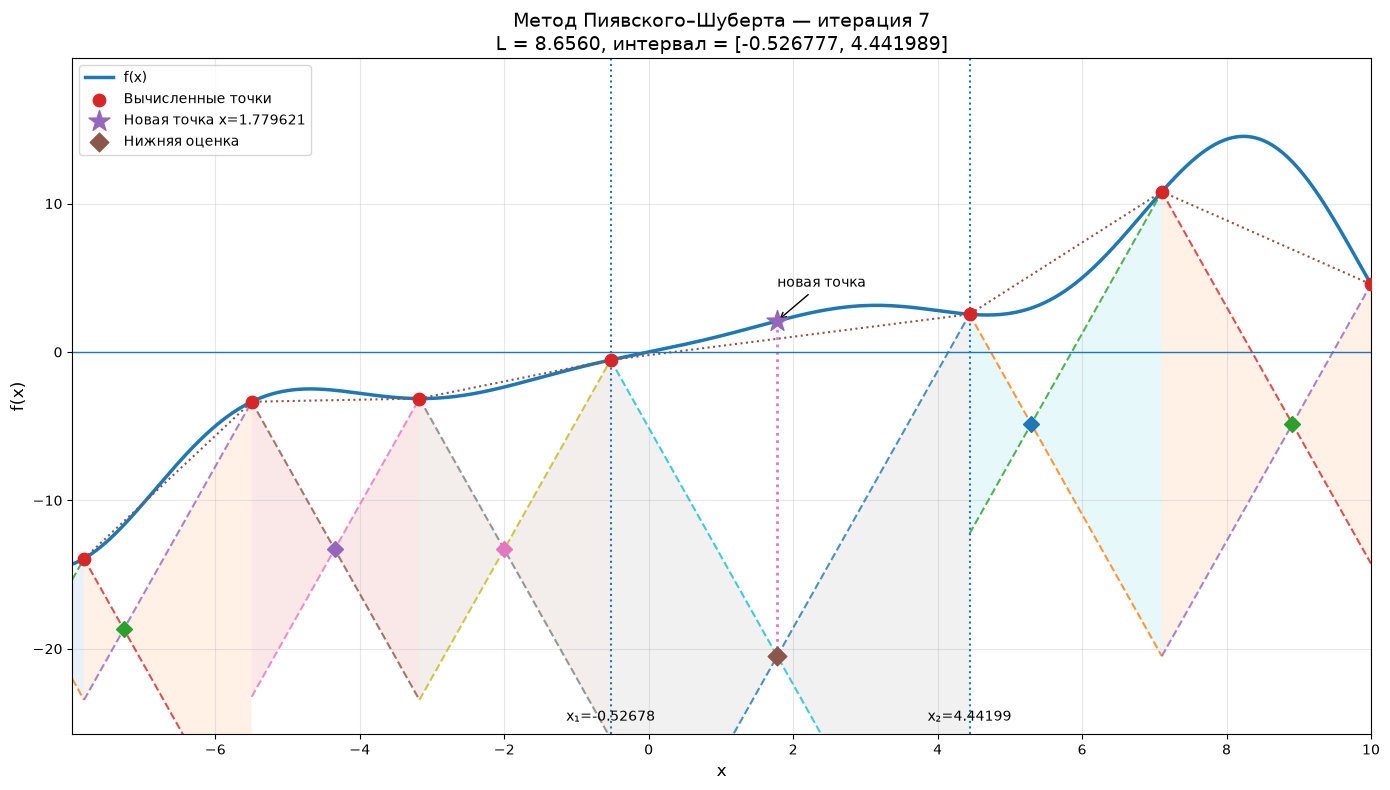

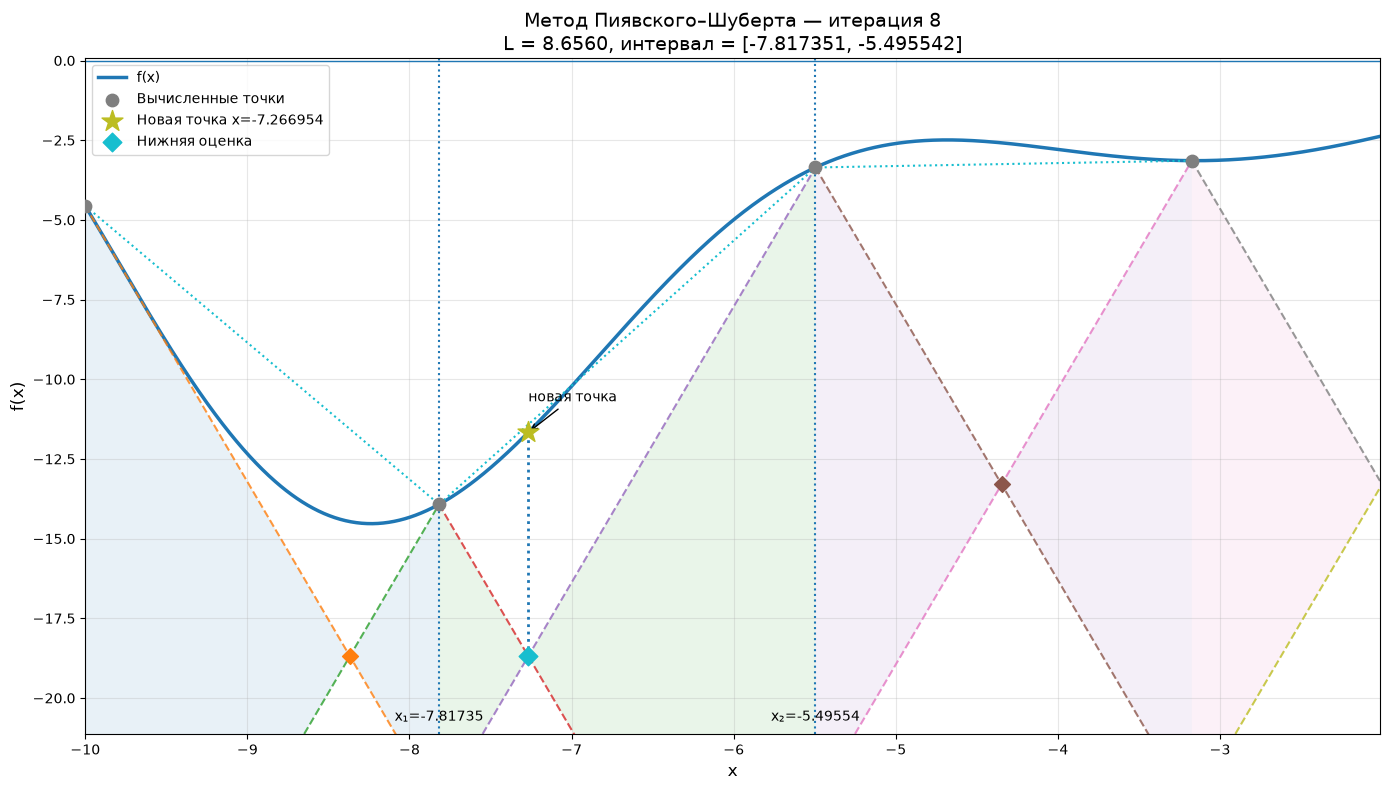

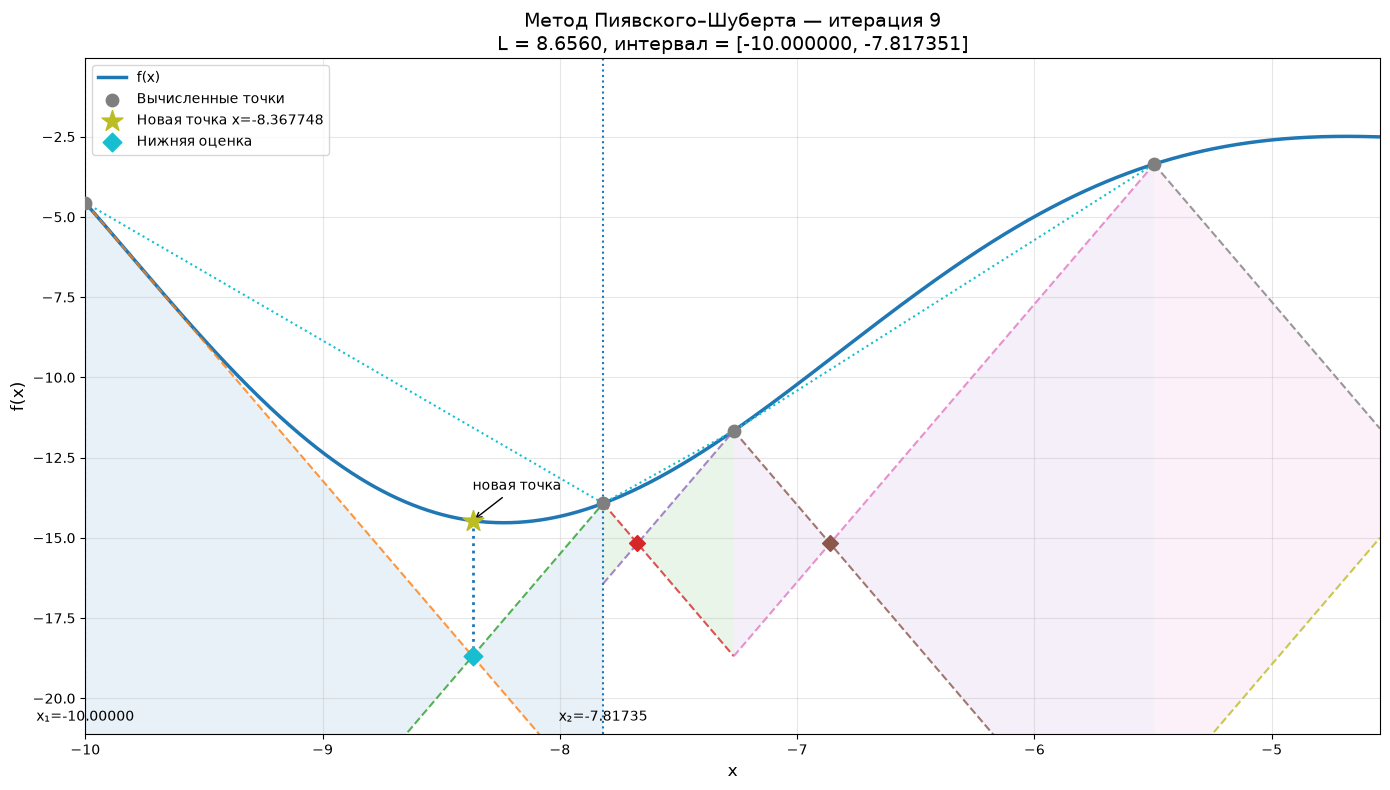

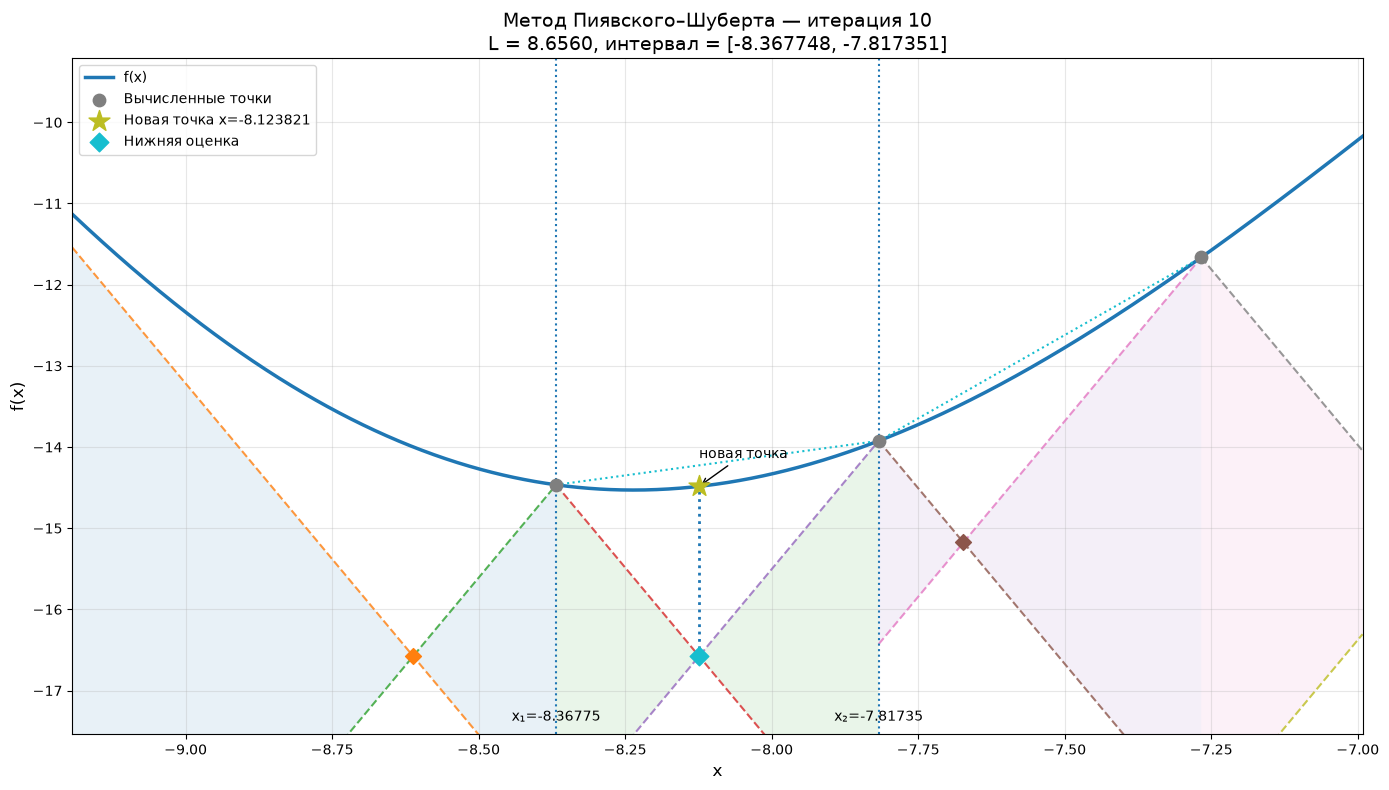

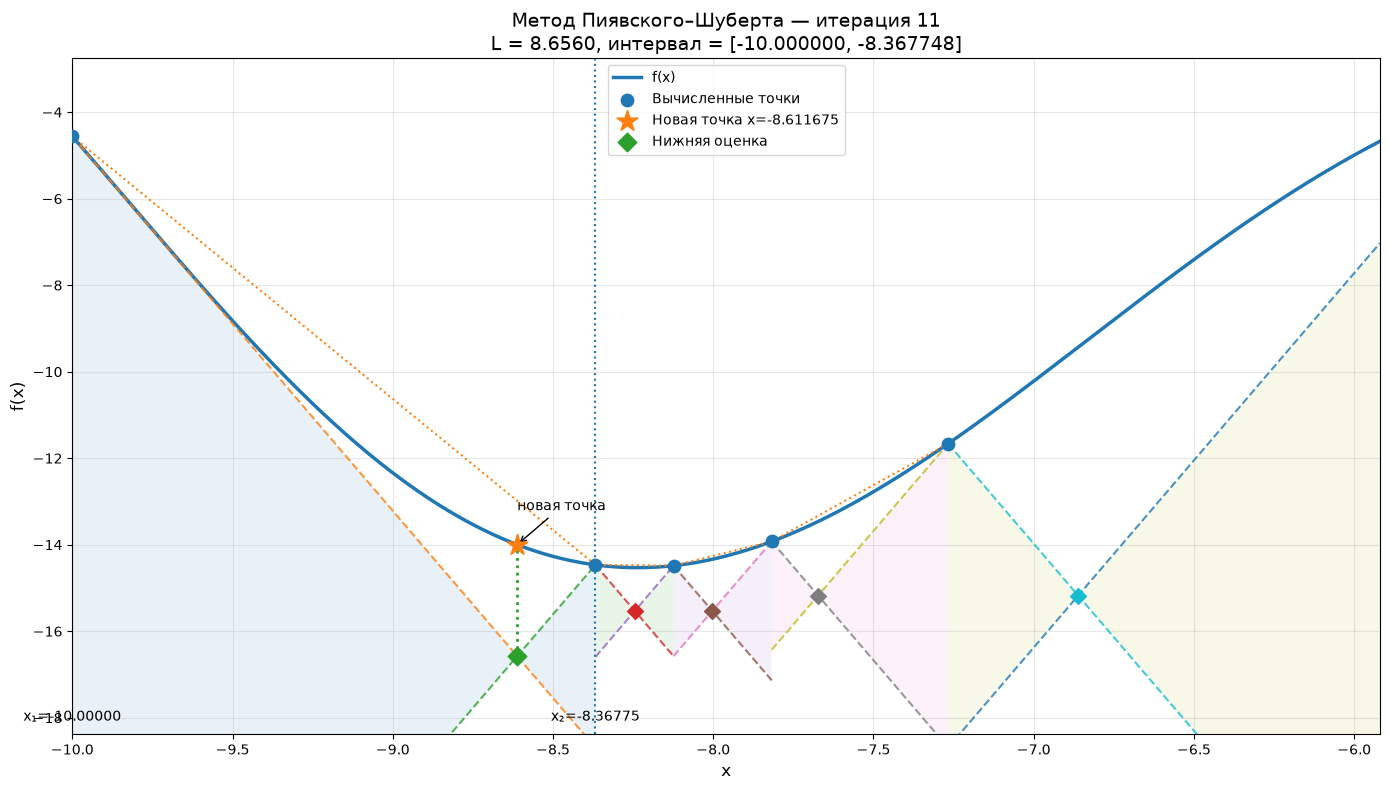

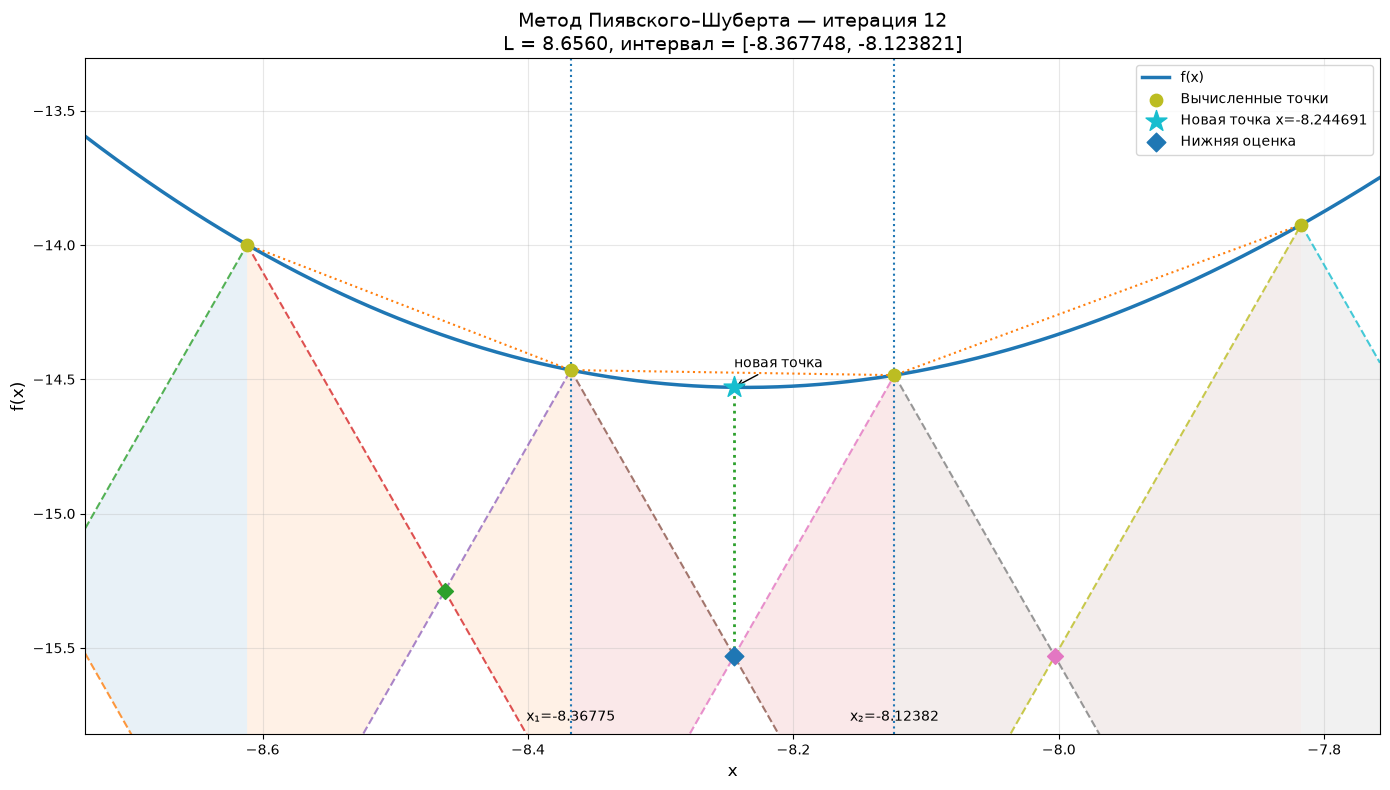

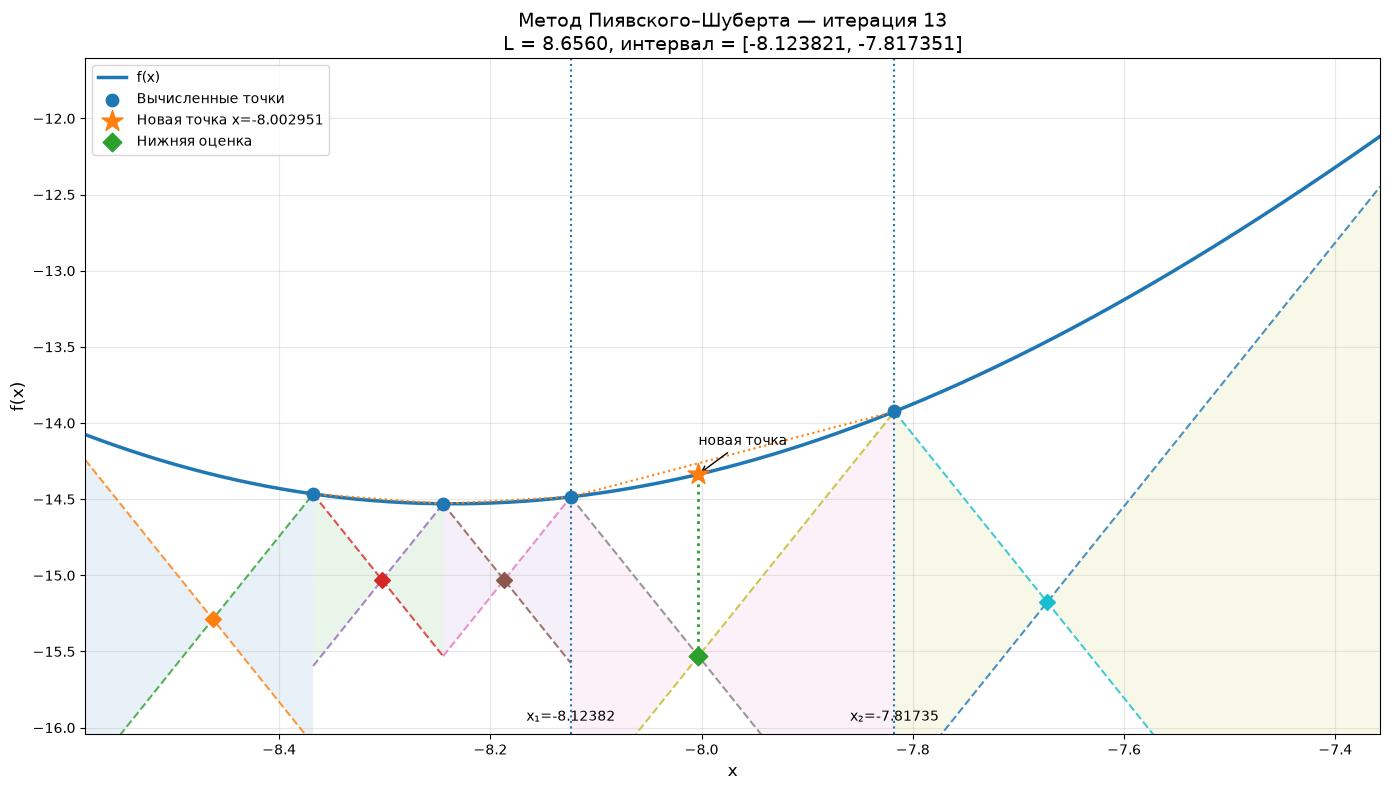

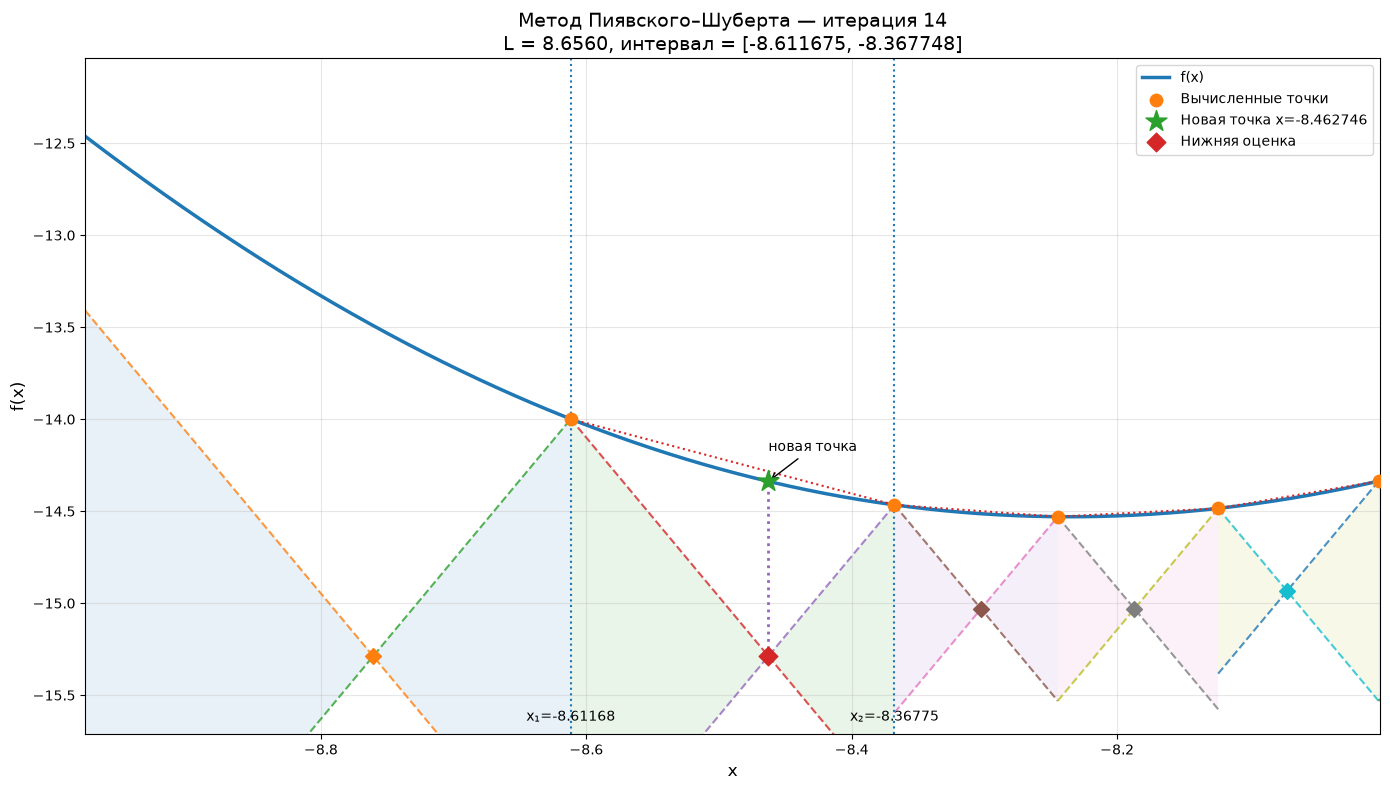

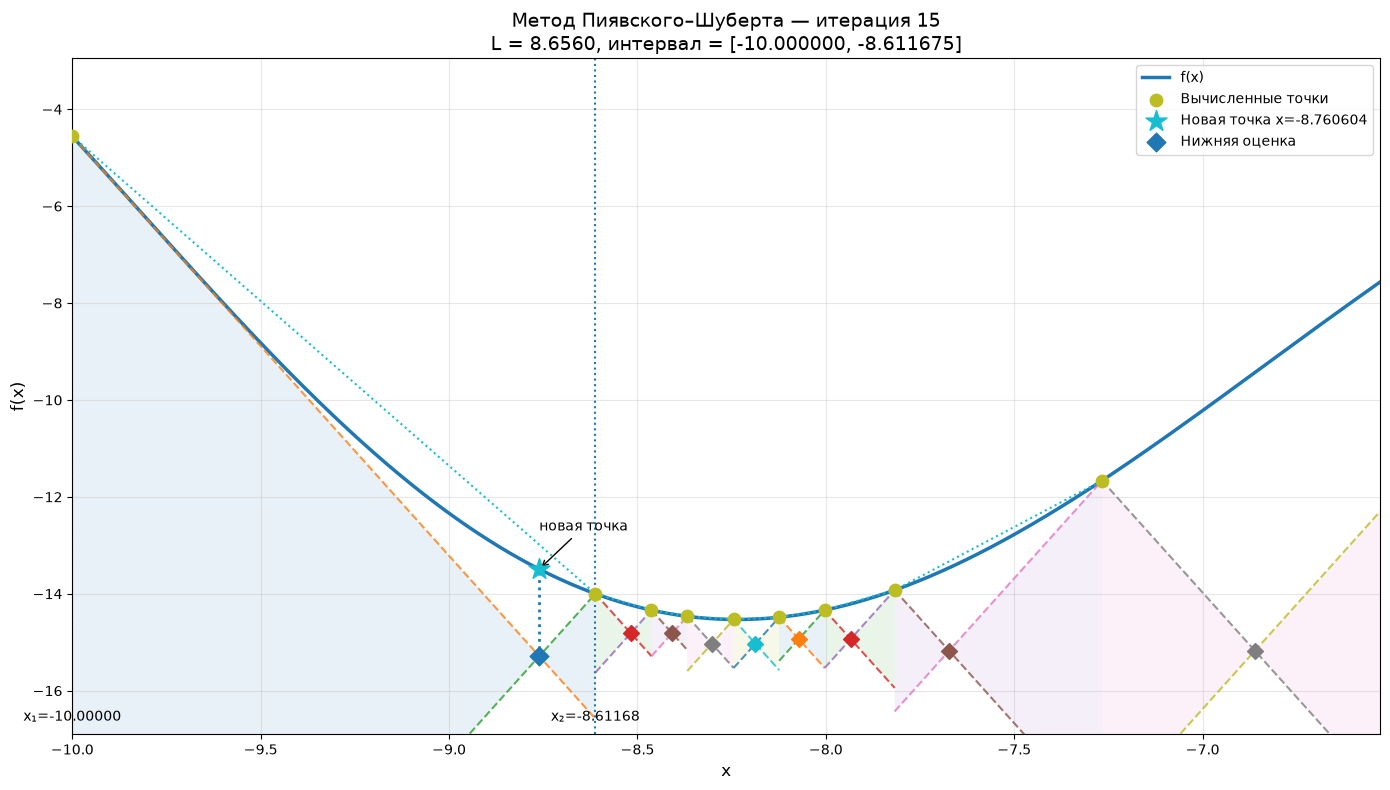

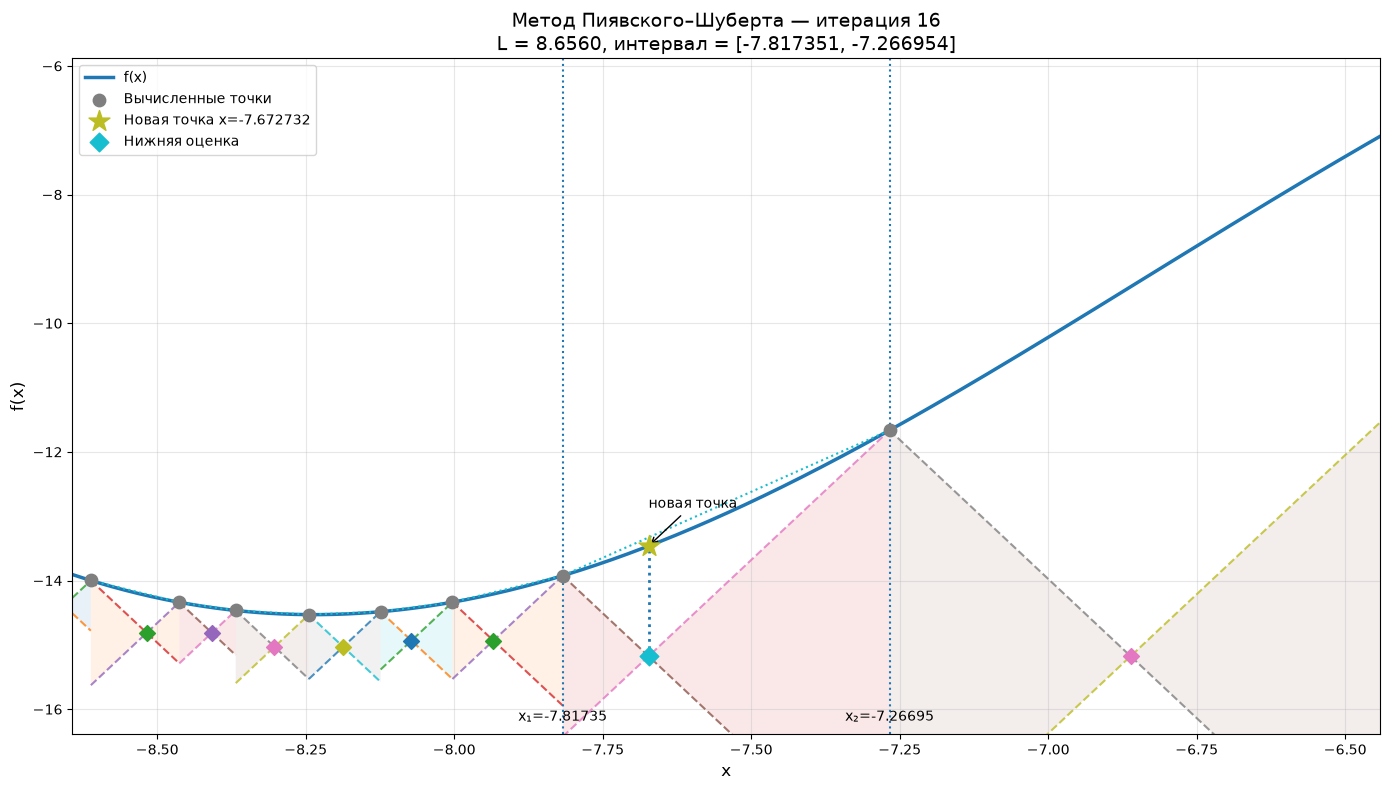

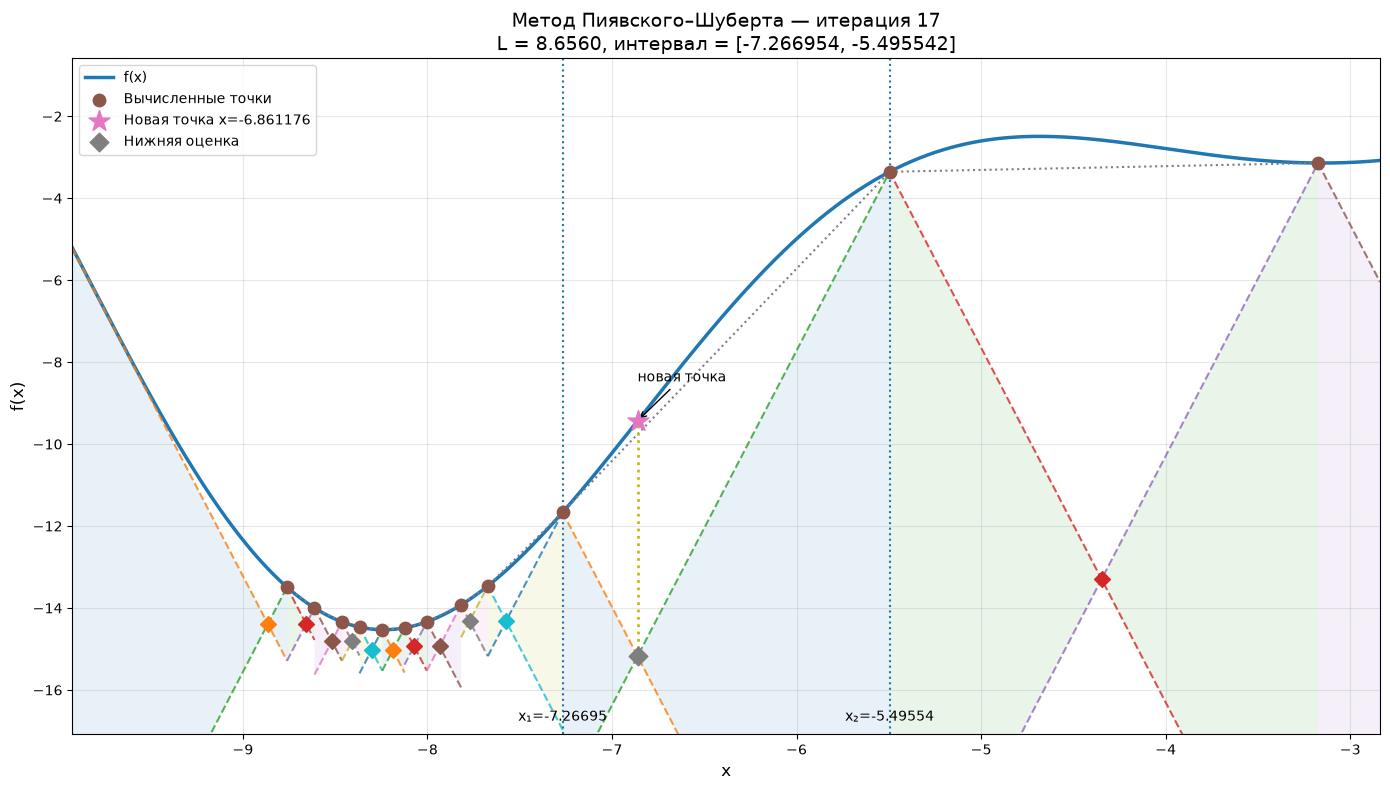

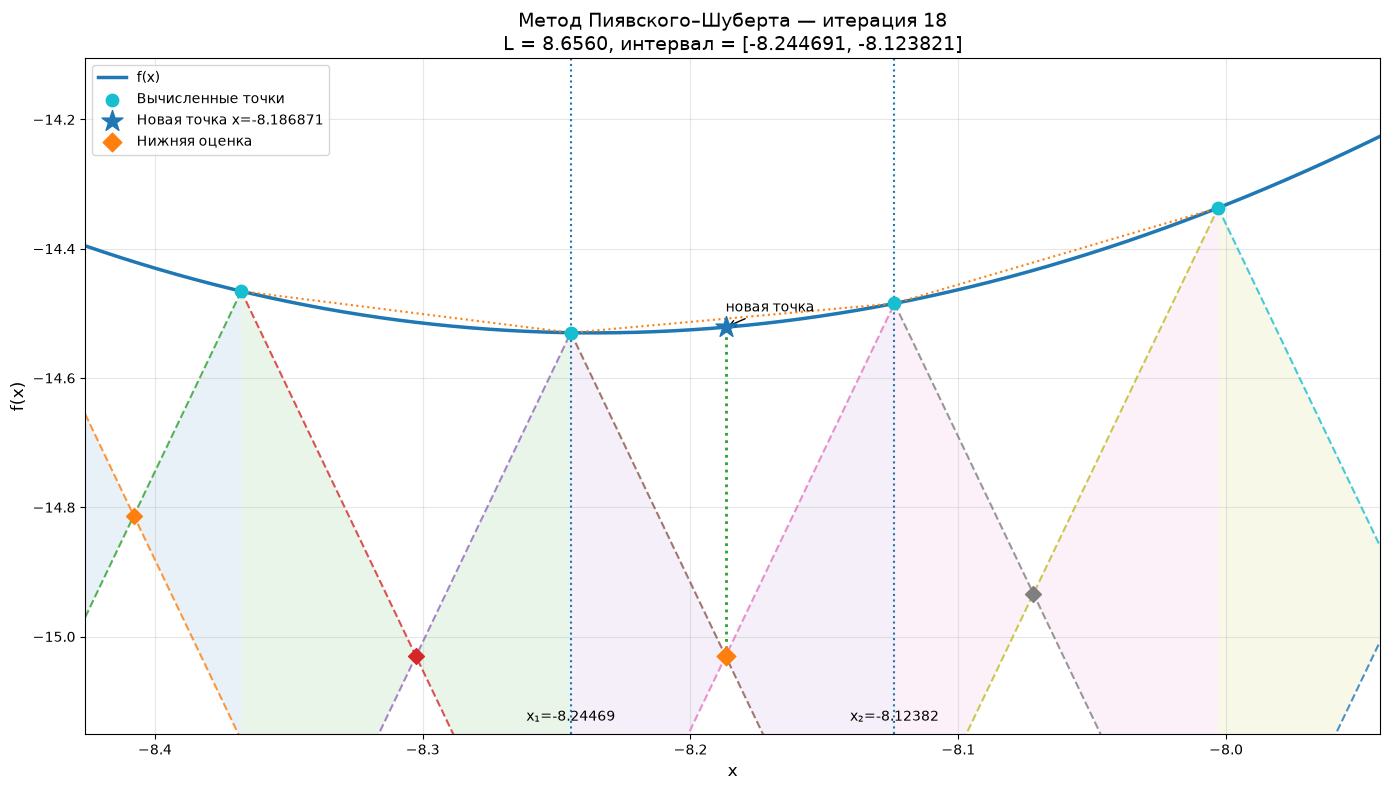

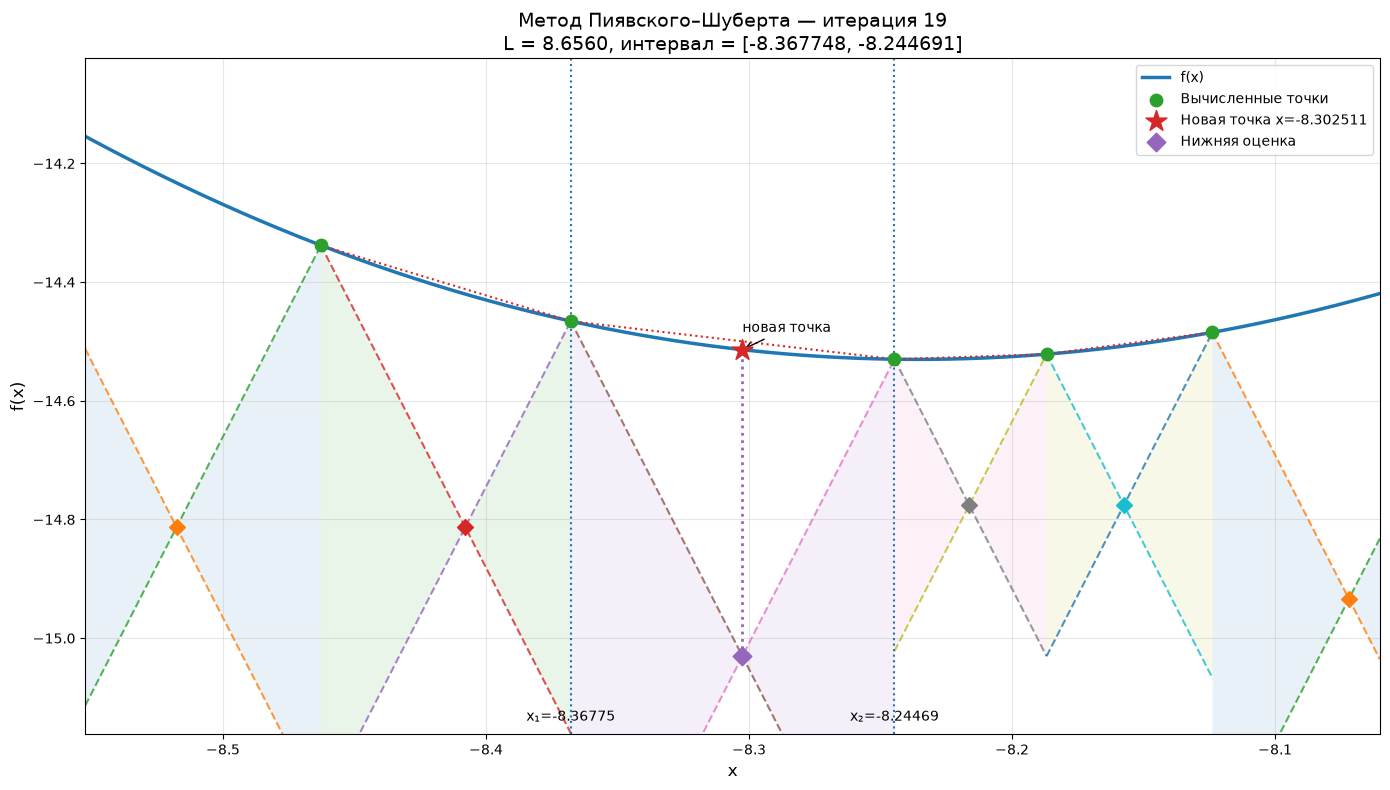

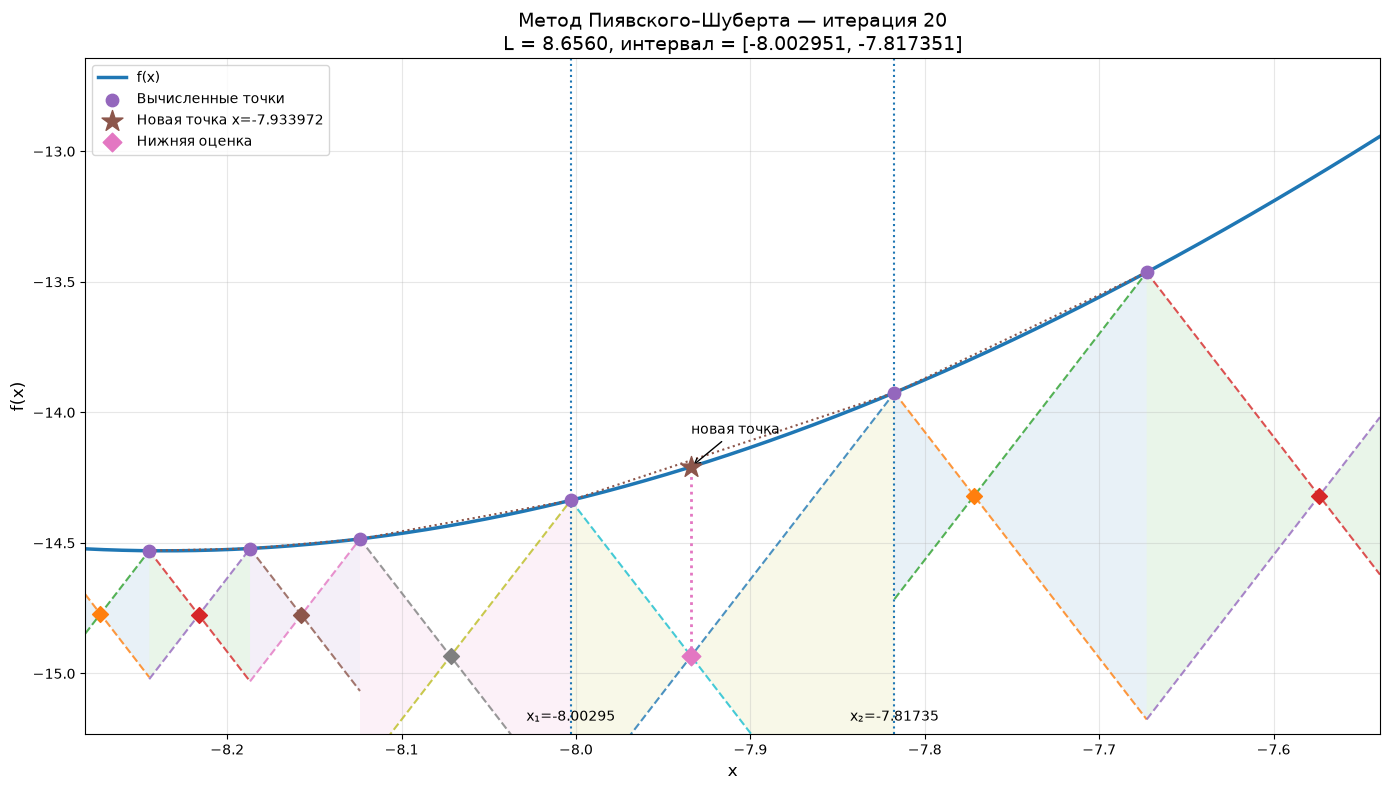

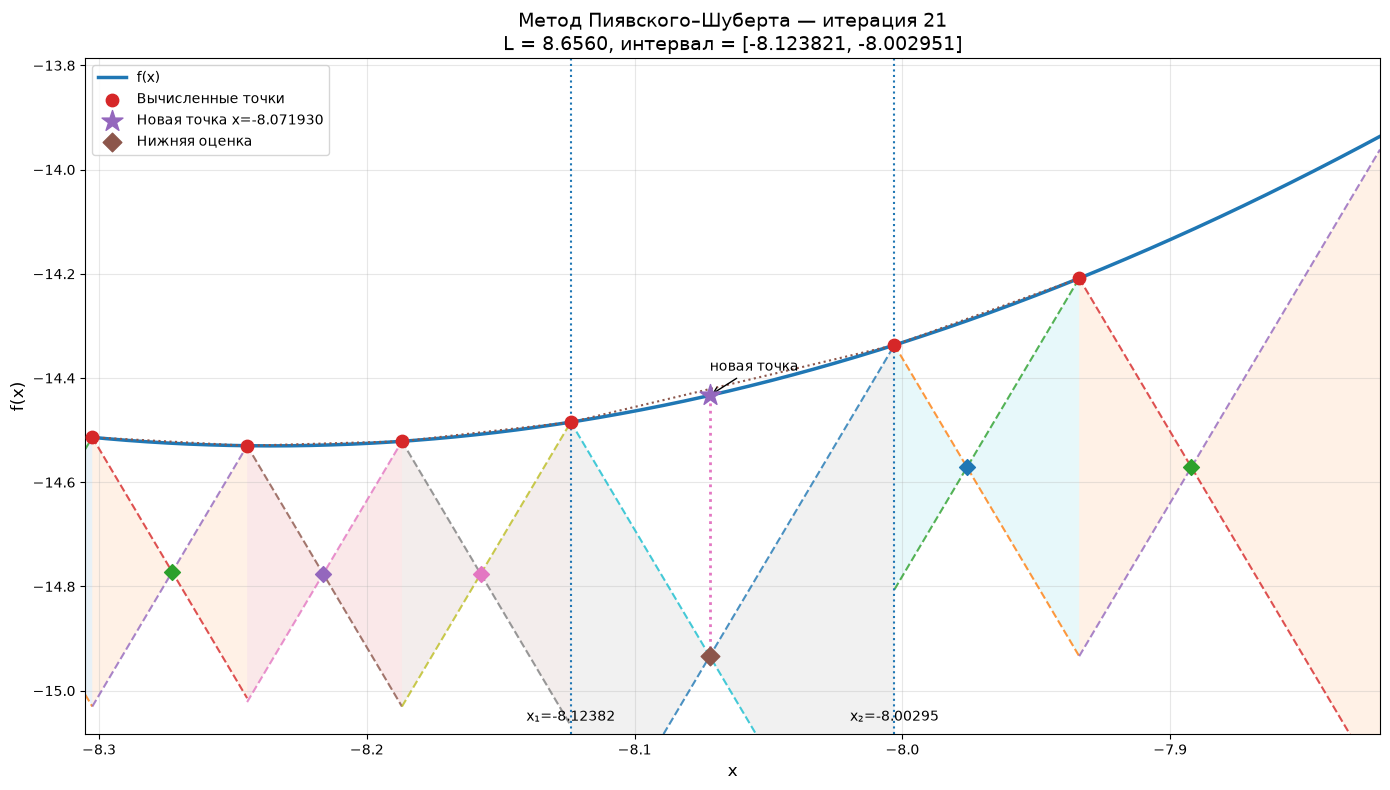

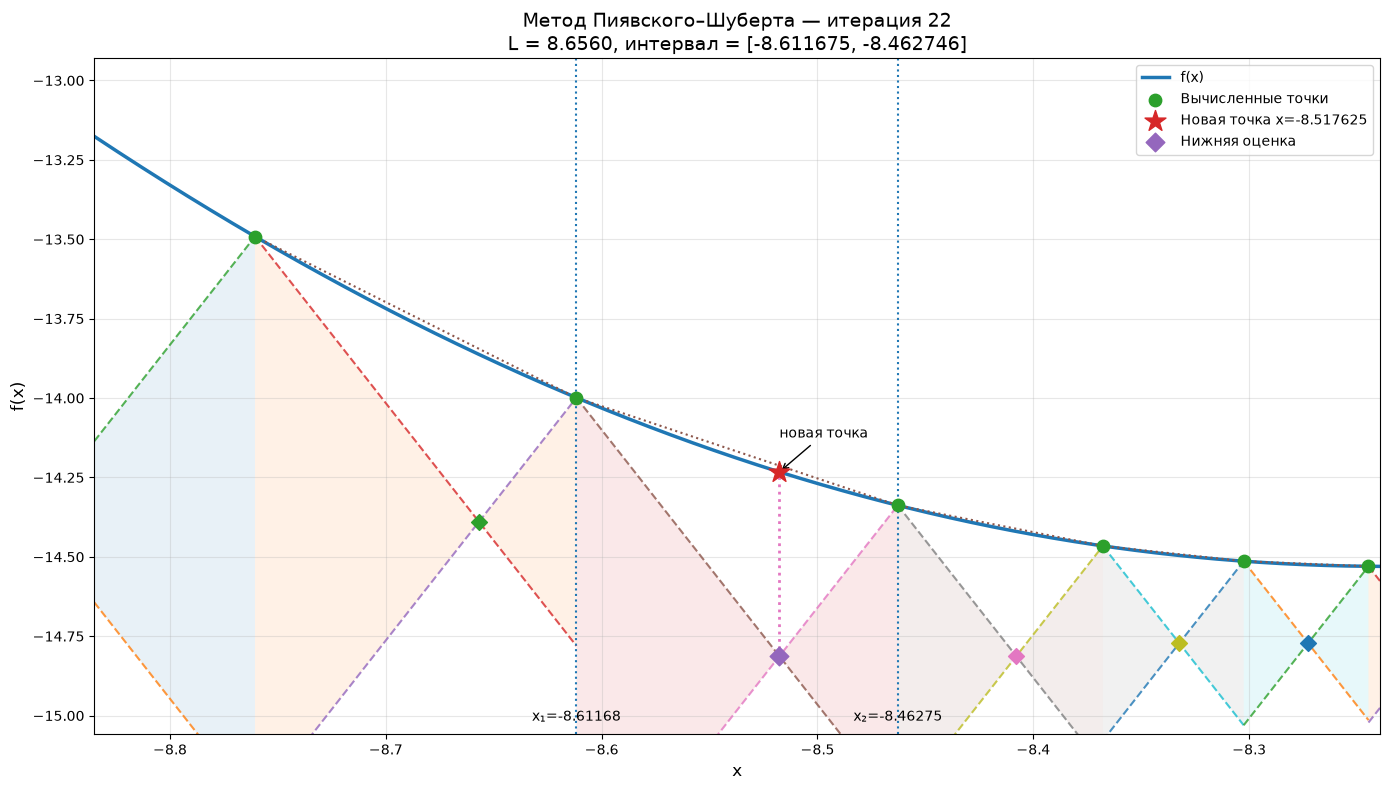

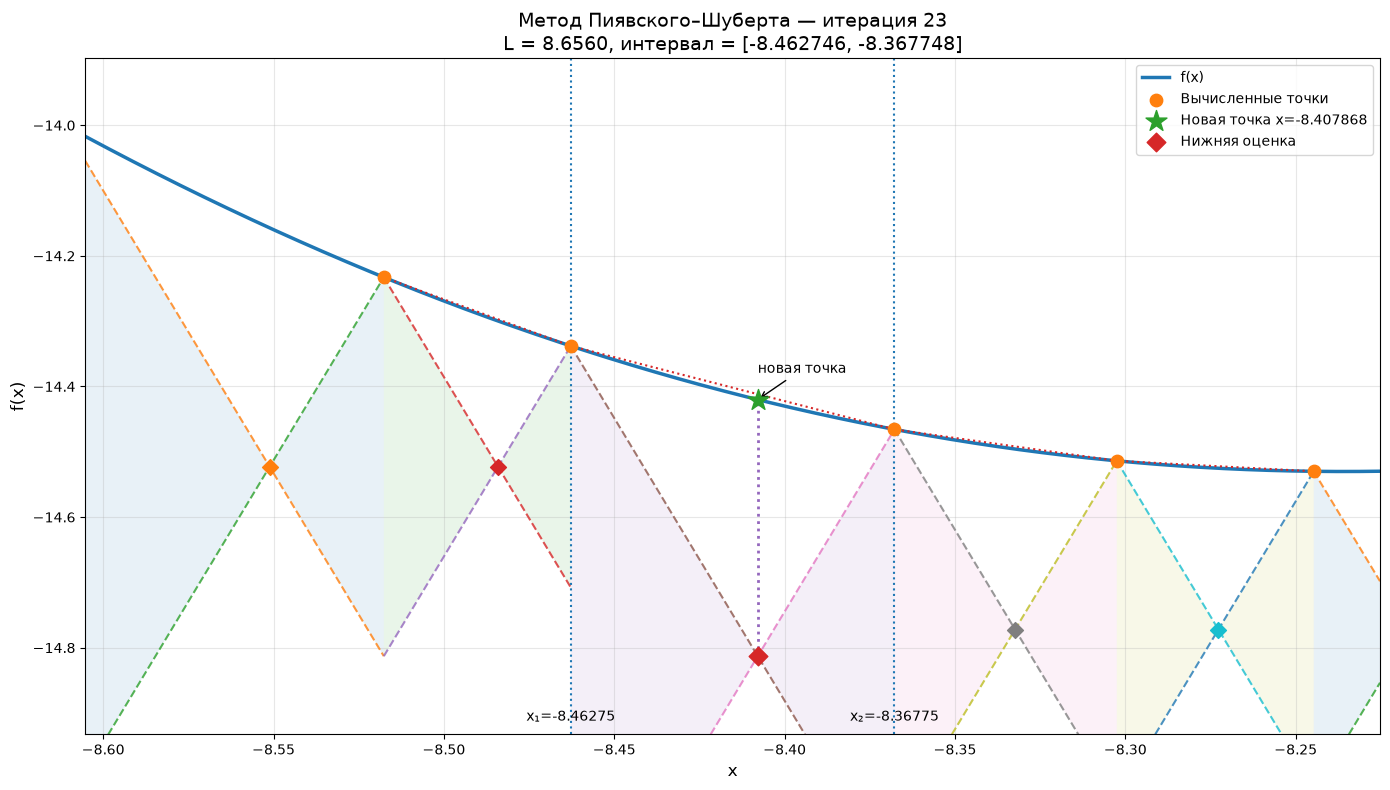

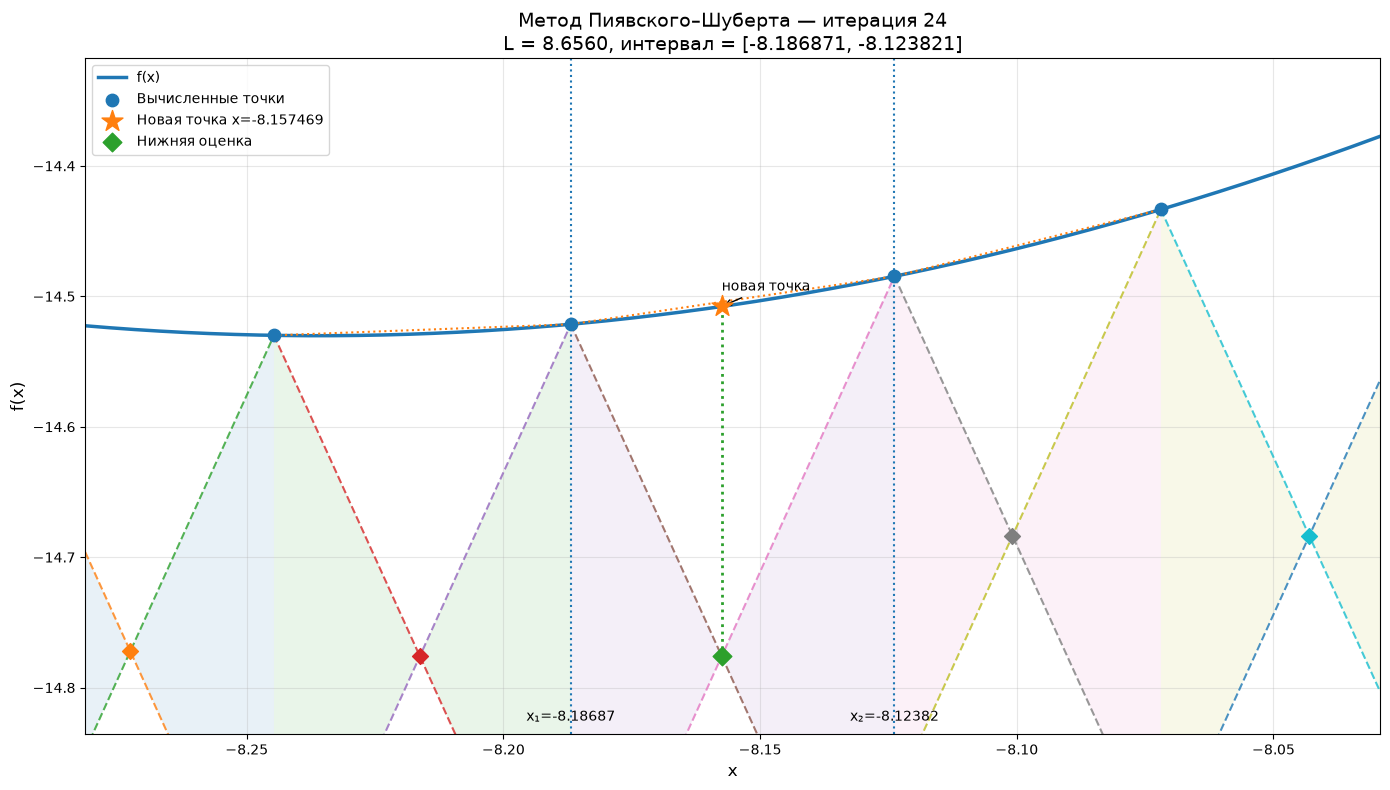

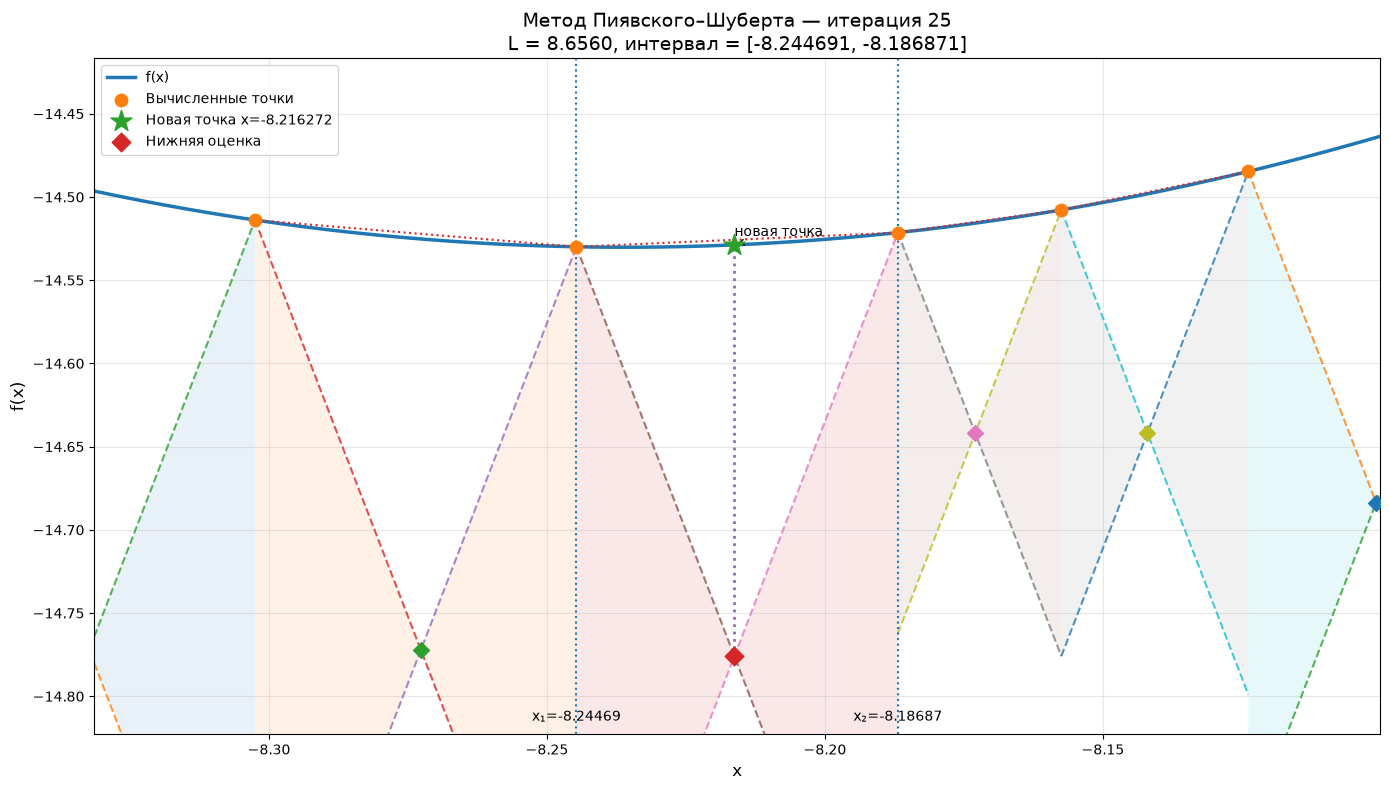

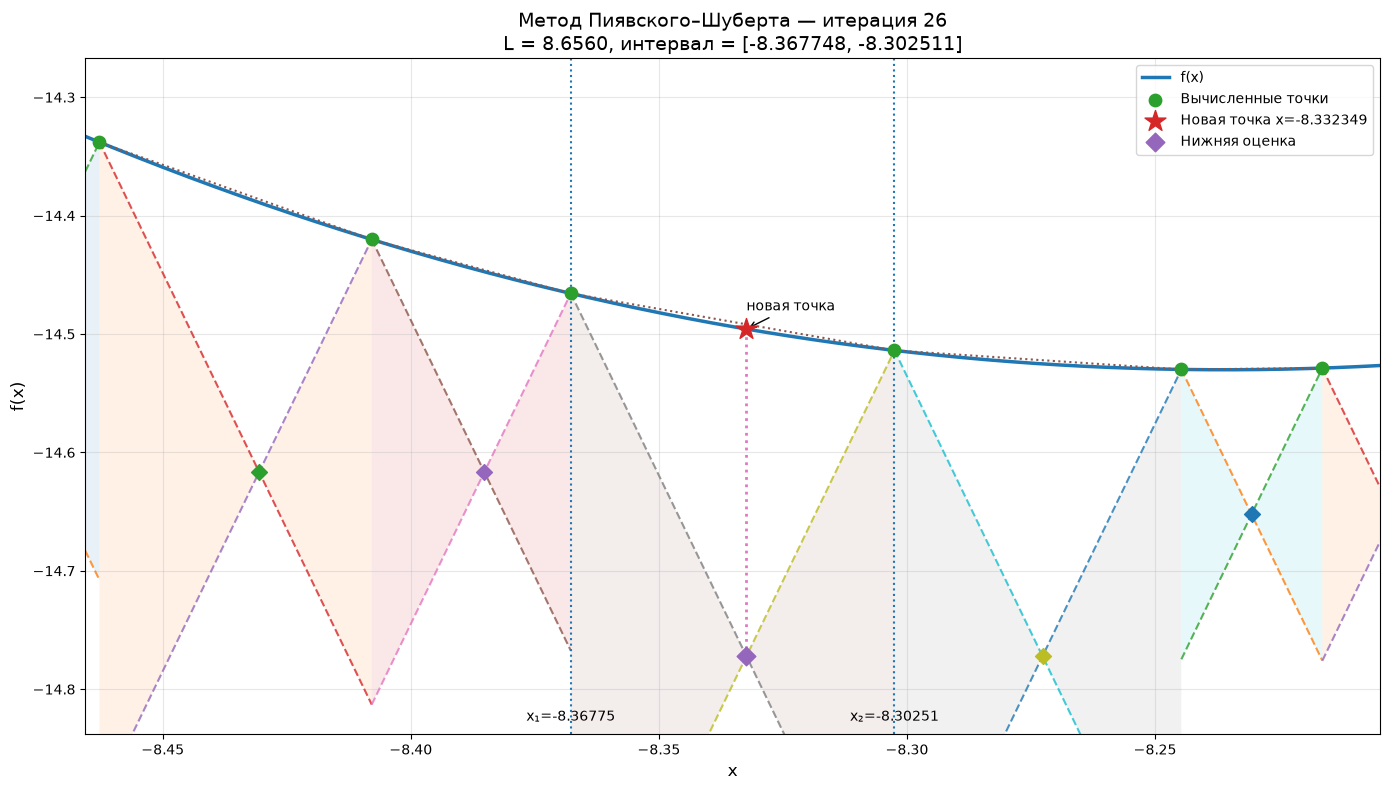

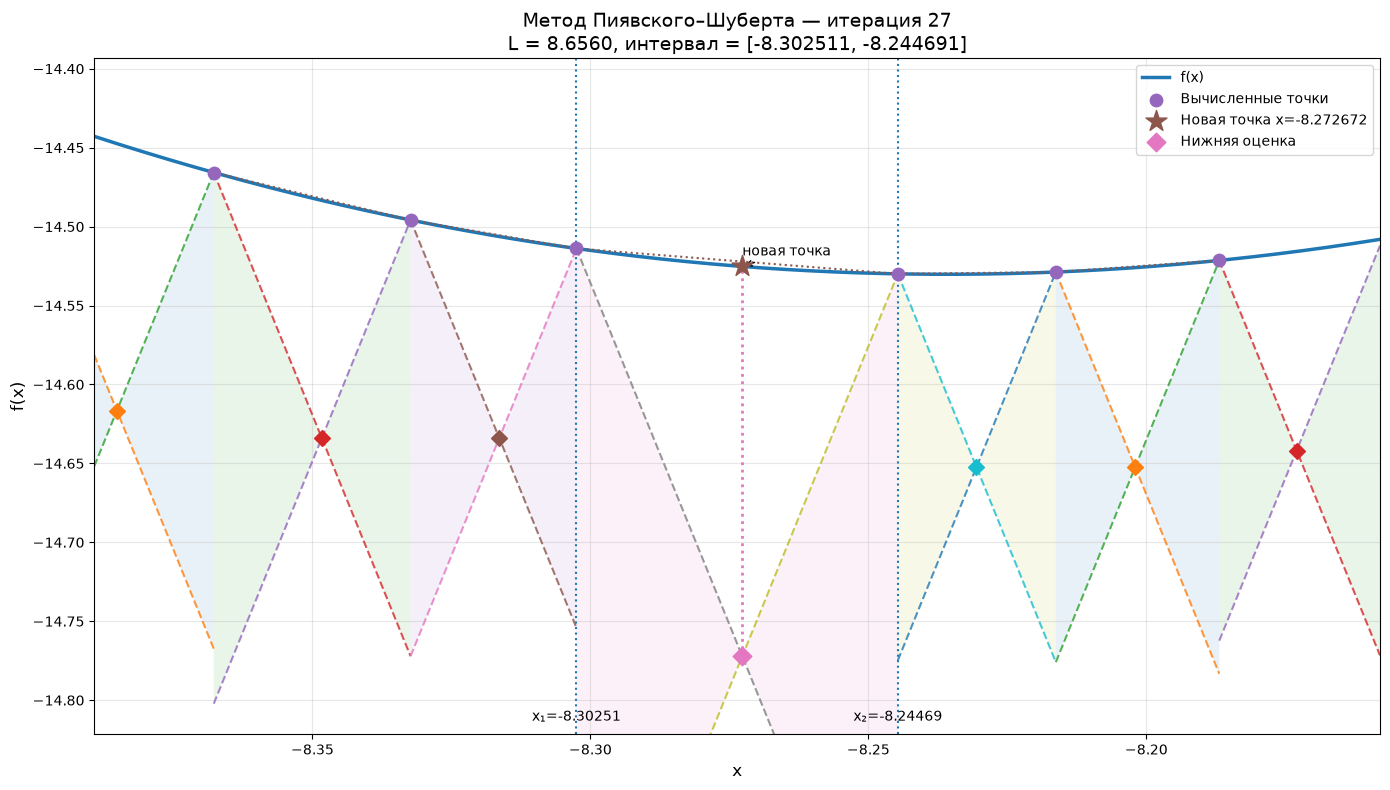

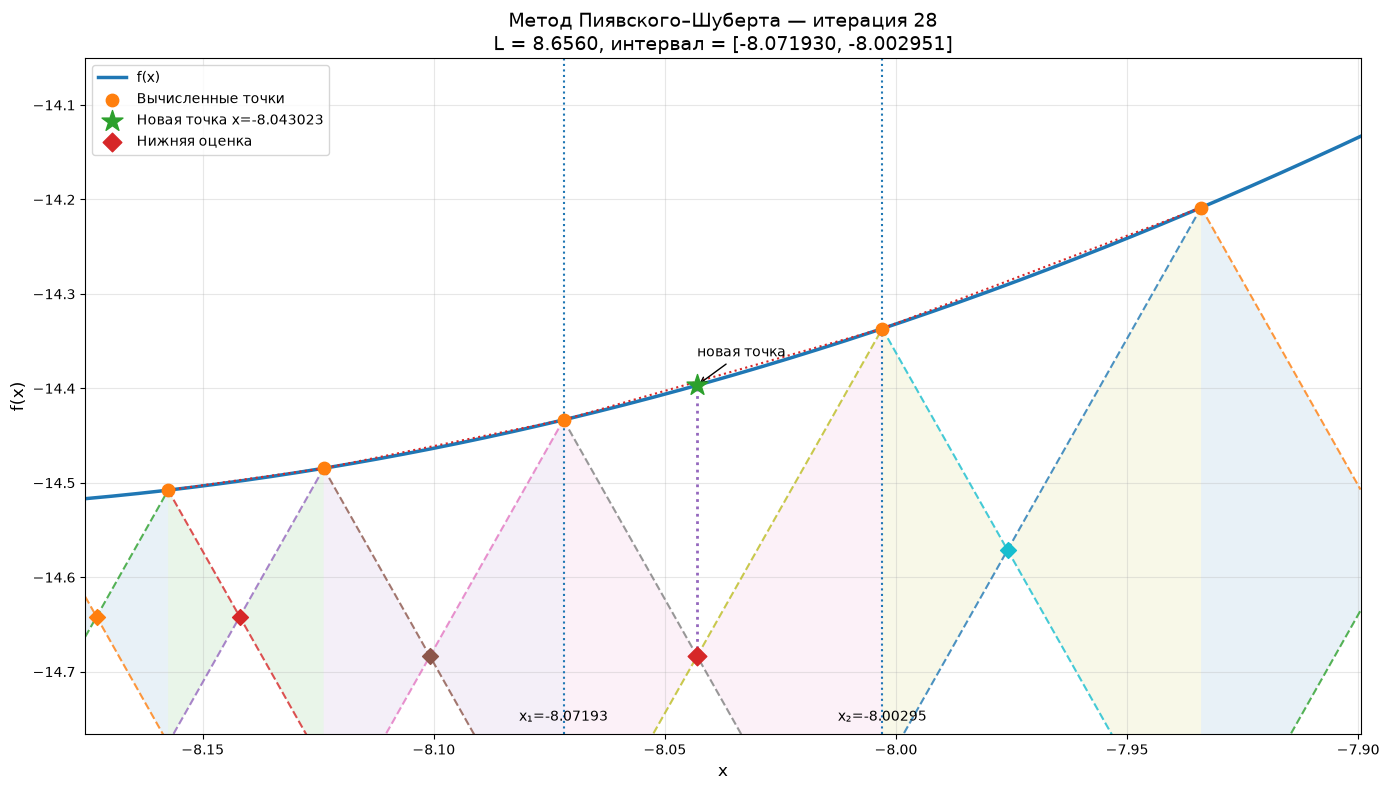

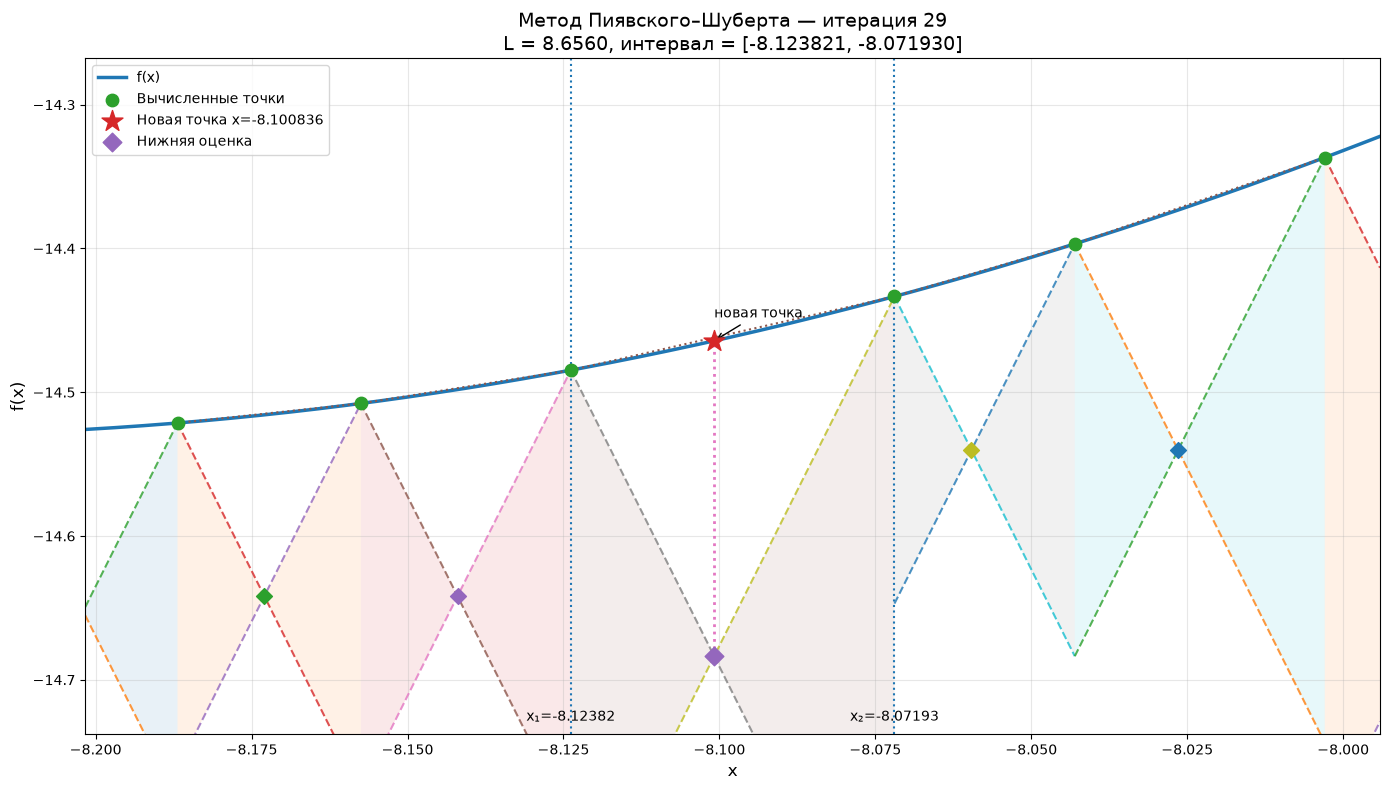

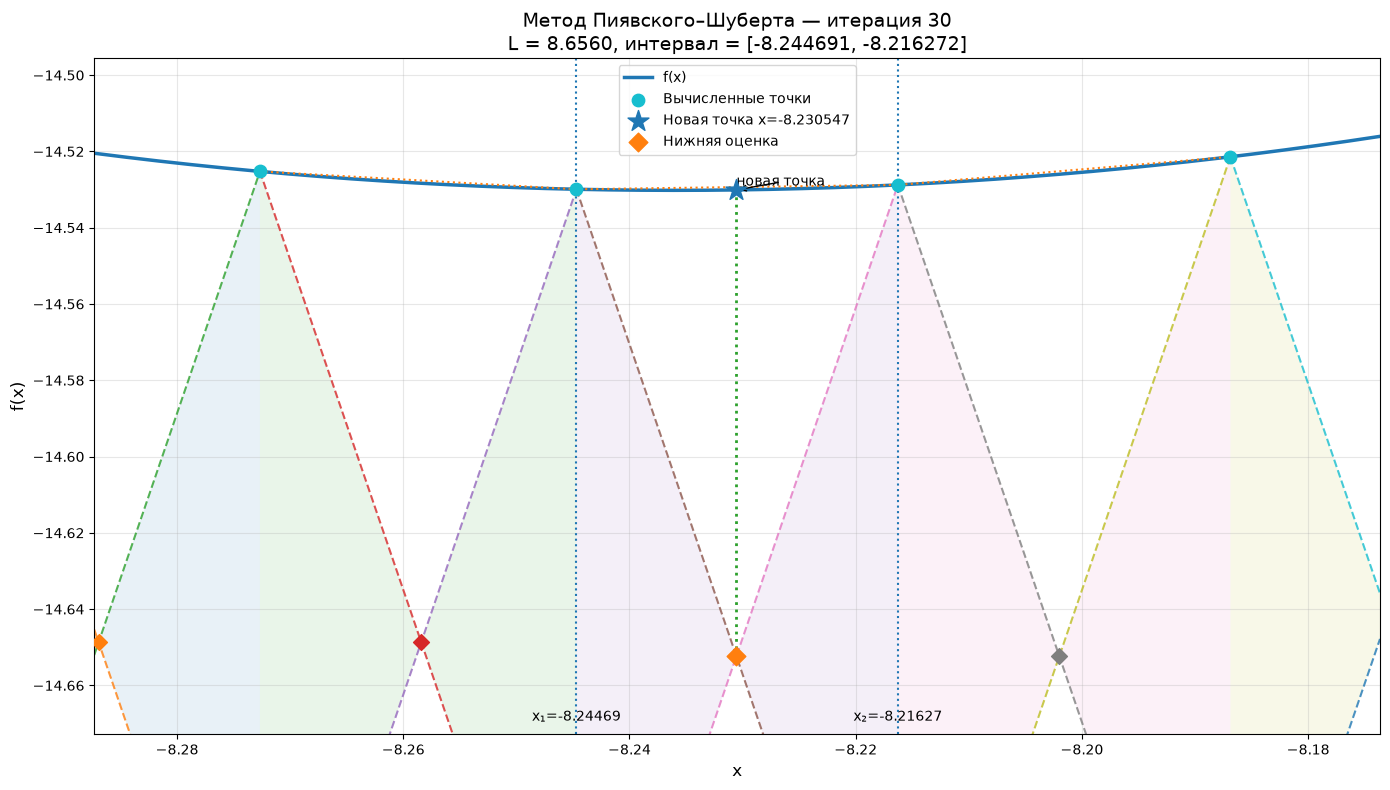

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


# ============================================================
# 1. ФУНКЦИЯ
# ============================================================

def f(x):
    return x + (x**2) * np.sin(x) / 10


def df(x):
    return 1 + (2 * x * np.sin(x) + x**2 * np.cos(x)) / 10


# ============================================================
# 2. ИНТЕРВАЛ ПОИСКА
# ============================================================

a = -10
b = 10

N = 2000

x_grid = np.linspace(a, b, N)

func_grid = f(x_grid)
df_grid = df(x_grid)


# ============================================================
# 3. КОНСТАНТА ЛИПШИЦА
# ============================================================
#
# |f(x) - f(y)| <= L |x-y|
#
# Для дифференцируемой функции достаточно:
#
# L >= max |f'(x)|
#
# ============================================================

L = np.max(np.abs(df_grid))

print(f"Константа Липшица L = {L:.8f}")


# ============================================================
# 4. ФУНКЦИИ ЛИПШИЦЕВСКИХ ПРЯМЫХ
# ============================================================

def upper_line(x, xi, fi):
    """
    Верхняя прямая:
        f(xi) + L |x - xi|
    """
    return fi + L * np.abs(x - xi)


def lower_line(x, xi, fi):
    """
    Нижняя прямая:
        f(xi) - L |x - xi|
    """
    return fi - L * np.abs(x - xi)


# ============================================================
# 5. ТЕКУЩАЯ ЛИПШИЦЕВСКАЯ ОЦЕНКА
# ============================================================

def lipschitz_lower_bound(x, points_x, points_f):
    """
    Нижняя оценка функции в точке x:

        max_i [f(x_i) - L |x-x_i|]

    Поскольку функция удовлетворяет условию Липшица,
    эта величина не превышает настоящую f(x).
    """

    values = []

    for xi, fi in zip(points_x, points_f):
        values.append(fi - L * abs(x - xi))

    return max(values)


# ============================================================
# 6. КАНДИДАТ В ИНТЕРВАЛЕ
# ============================================================

def interval_candidate(x1, f1, x2, f2):
    """
    Для двух соседних точек:

             f1
             *
            / \
           /   \
          /     \
         *-------*
        x1       x2
                 f2

    Пересечение двух нижних прямых:

        f1 - L(x-x1)
        f2 - L(x2-x)

    даёт:

        x_new =
            (x1+x2)/2 + (f1-f2)/(2L)

    """

    x_new = (
        (x1 + x2) / 2
        + (f1 - f2) / (2 * L)
    )

    # Чтобы из-за численных ошибок
    # не выйти за интервал
    x_new = np.clip(x_new, x1, x2)

    # Нижняя граница в этой точке
    lower_bound = (
        f1 - L * (x_new - x1)
    )

    return x_new, lower_bound


# ============================================================
# 7. МЕТОД PIYAVSKII-SHUBERT
# ============================================================

eps = 1e-5
max_iter = 30


# Начальные точки
points_x = np.array([a, b], dtype=float)

points_f = np.array([
    f(a),
    f(b)
], dtype=float)


# История для визуализации
history = []


for iteration in range(max_iter):

    # --------------------------------------------------------
    # Сортируем точки
    # --------------------------------------------------------

    order = np.argsort(points_x)

    points_x = points_x[order]
    points_f = points_f[order]


    # --------------------------------------------------------
    # Ищем лучший интервал
    # --------------------------------------------------------

    candidates = []

    for i in range(len(points_x) - 1):

        x1 = points_x[i]
        x2 = points_x[i + 1]

        f1 = points_f[i]
        f2 = points_f[i + 1]


        # Кандидат
        x_new, lower_bound = interval_candidate(
            x1,
            f1,
            x2,
            f2
        )


        candidates.append({
            "index": i,
            "x": x_new,
            "lower_bound": lower_bound,
            "x1": x1,
            "x2": x2,
            "f1": f1,
            "f2": f2
        })


    # --------------------------------------------------------
    # Выбираем интервал с минимальной нижней оценкой
    # --------------------------------------------------------

    best = min(
        candidates,
        key=lambda c: c["lower_bound"]
    )


    x_new = best["x"]


    # --------------------------------------------------------
    # Проверка расстояния до существующих точек
    # --------------------------------------------------------

    if np.min(np.abs(points_x - x_new)) < eps:

        print(
            "Новая точка слишком близка к существующей."
        )

        break


    # --------------------------------------------------------
    # Вычисляем функцию
    # --------------------------------------------------------

    f_new = f(x_new)


    # --------------------------------------------------------
    # Сохраняем состояние ДО добавления новой точки
    # --------------------------------------------------------

    history.append({
        "iteration": iteration + 1,
        "points_x": points_x.copy(),
        "points_f": points_f.copy(),

        "x_new": x_new,
        "f_new": f_new,

        "selected_x1": best["x1"],
        "selected_x2": best["x2"],
        "selected_f1": best["f1"],
        "selected_f2": best["f2"],

        "lower_bound": best["lower_bound"]
    })


    # --------------------------------------------------------
    # Добавляем новую точку
    # --------------------------------------------------------

    points_x = np.append(
        points_x,
        x_new
    )

    points_f = np.append(
        points_f,
        f_new
    )


    # --------------------------------------------------------
    # Критерий остановки
    # --------------------------------------------------------

    best_f = np.min(points_f)

    # Теоретически можно остановиться,
    # если разница между лучшей найденной точкой
    # и минимальной нижней оценкой мала.

    global_lower_bound = min(
        c["lower_bound"]
        for c in candidates
    )

    if best_f - global_lower_bound < eps:

        print(
            f"\nСходимость достигнута "
            f"за {iteration + 1} итераций."
        )

        break


# ============================================================
# 8. РЕЗУЛЬТАТ
# ============================================================

best_index = np.argmin(points_f)

x_min = points_x[best_index]
f_min = points_f[best_index]


print()
print("=" * 60)
print("РЕЗУЛЬТАТ")
print("=" * 60)

print(f"Константа Липшица L = {L:.10f}")
print(f"Минимум x = {x_min:.10f}")
print(f"f(x)      = {f_min:.10f}")
print(f"Итераций  = {len(history)}")


# ============================================================
# 9. ВИЗУАЛИЗАЦИЯ ОДНОГО ШАГА
# ============================================================

def plot_iteration(state, zoom=True):
    """
    Адаптивная визуализация одной итерации.

    zoom=True:
        автоматически приближает область около текущего
        выбранного интервала.
    """

    px = state["points_x"]
    pf = state["points_f"]

    x_new = state["x_new"]

    # ========================================================
    # 1. Определяем выбранный интервал
    # ========================================================

    x1 = state["selected_x1"]
    x2 = state["selected_x2"]

    interval_width = x2 - x1

    interval_center = (x1 + x2) / 2


    # ========================================================
    # 2. АДАПТИВНЫЙ МАСШТАБ ПО X
    # ========================================================

    if zoom:

        # Показываем выбранный интервал примерно
        # в центральных 50-60% графика.
        #
        # Поэтому берём область шире самого интервала.

        padding = interval_width * 1.5

        x_min_view = x1 - padding
        x_max_view = x2 + padding


        # ----------------------------------------------------
        # Не позволяем окну стать слишком большим
        # ----------------------------------------------------

        x_min_view = max(a, x_min_view)
        x_max_view = min(b, x_max_view)


        # ----------------------------------------------------
        # Если интервал очень большой — показываем
        # весь исходный диапазон
        # ----------------------------------------------------

        if x_max_view - x_min_view > 0.9 * (b - a):

            x_min_view = a
            x_max_view = b


    else:

        x_min_view = a
        x_max_view = b


    # ========================================================
    # 3. СЕТКА ДЛЯ ЛОКАЛЬНОГО ГРАФИКА
    # ========================================================

    x_local = np.linspace(
        x_min_view,
        x_max_view,
        1200
    )

    y_local = f(x_local)


    # ========================================================
    # 4. СОЗДАЁМ FIGURE
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(14, 8)
    )


    # ========================================================
    # 5. ОСНОВНАЯ ФУНКЦИЯ
    # ========================================================

    ax.plot(
        x_local,
        y_local,
        linewidth=2.5,
        label="f(x)"
    )


    # ========================================================
    # 6. ЛИПШИЦЕВСКИЕ РОМБЫ
    # ========================================================

    for i in range(len(px) - 1):

        xi = px[i]
        xj = px[i + 1]

        fi = pf[i]
        fj = pf[i + 1]


        # Если интервал полностью вне области просмотра,
        # его можно не рисовать.

        if xj < x_min_view or xi > x_max_view:
            continue


        # ----------------------------------------------------
        # Ограничиваем интервал областью просмотра
        # ----------------------------------------------------

        left = max(xi, x_min_view)
        right = min(xj, x_max_view)

        x_interval = np.linspace(
            left,
            right,
            200
        )


        # ----------------------------------------------------
        # Нижняя прямая от левой точки
        # ----------------------------------------------------

        y_left = (
            fi
            - L * (x_interval - xi)
        )


        # ----------------------------------------------------
        # Нижняя прямая от правой точки
        # ----------------------------------------------------

        y_right = (
            fj
            - L * (xj - x_interval)
        )


        # ----------------------------------------------------
        # Рисуем две прямые
        # ----------------------------------------------------

        ax.plot(
            x_interval,
            y_left,
            "--",
            linewidth=1.5,
            alpha=0.8
        )

        ax.plot(
            x_interval,
            y_right,
            "--",
            linewidth=1.5,
            alpha=0.8
        )


        # ----------------------------------------------------
        # Заполняем "ромб"
        # ----------------------------------------------------

        ax.fill_between(
            x_interval,
            y_left,
            y_right,
            alpha=0.10
        )


        # ----------------------------------------------------
        # Точка пересечения прямых
        # ----------------------------------------------------

        xc, yc = interval_candidate(
            xi,
            fi,
            xj,
            fj
        )


        # Показываем ромбовую вершину
        if x_min_view <= xc <= x_max_view:

            ax.scatter(
                xc,
                yc,
                marker="D",
                s=65,
                zorder=10
            )


    # ========================================================
    # 7. ВЫЧИСЛЕННЫЕ ТОЧКИ
    # ========================================================

    visible = (
        (px >= x_min_view)
        &
        (px <= x_max_view)
    )

    ax.scatter(
        px[visible],
        pf[visible],
        s=80,
        zorder=20,
        label="Вычисленные точки"
    )


    # ========================================================
    # 8. СОЕДИНЕНИЕ ТОЧЕК
    # ========================================================

    visible_x = px[visible]
    visible_f = pf[visible]

    if len(visible_x) > 1:

        order = np.argsort(visible_x)

        ax.plot(
            visible_x[order],
            visible_f[order],
            ":",
            linewidth=1.5
        )


    # ========================================================
    # 9. ВЫДЕЛЯЕМ ВЫБРАННЫЙ ИНТЕРВАЛ
    # ========================================================

    ax.axvline(
        x1,
        linestyle=":",
        linewidth=1.5
    )

    ax.axvline(
        x2,
        linestyle=":",
        linewidth=1.5
    )


    # --------------------------------------------------------
    # Подписываем границы интервала
    # --------------------------------------------------------

    ax.text(
        x1,
        0.02,
        f"x₁={x1:.5f}",
        transform=ax.get_xaxis_transform(),
        ha="center"
    )

    ax.text(
        x2,
        0.02,
        f"x₂={x2:.5f}",
        transform=ax.get_xaxis_transform(),
        ha="center"
    )


    # ========================================================
    # 10. НОВАЯ ТОЧКА
    # ========================================================

    ax.scatter(
        x_new,
        state["f_new"],
        marker="*",
        s=250,
        zorder=30,
        label=f"Новая точка x={x_new:.6f}"
    )


    # ========================================================
    # 11. ТОЧКА МИНИМУМА ЛИПШИЦЕВСКОЙ ОЦЕНКИ
    # ========================================================

    ax.scatter(
        x_new,
        state["lower_bound"],
        marker="D",
        s=90,
        zorder=25,
        label="Нижняя оценка"
    )


    # ========================================================
    # 12. ВЕРТИКАЛЬНЫЙ ОТРЕЗОК
    # ========================================================

    ax.plot(
        [x_new, x_new],
        [
            state["lower_bound"],
            state["f_new"]
        ],
        ":",
        linewidth=2
    )


    # ========================================================
    # 13. ПОДПИСЫВАЕМ РОМБ
    # ========================================================

    ax.annotate(
        "новая точка",
        xy=(
            x_new,
            state["f_new"]
        ),
        xytext=(
            x_new,
            state["f_new"]
            + 0.08 * (
                np.max(y_local)
                - np.min(y_local)
            )
        ),
        arrowprops=dict(
            arrowstyle="->"
        ),
        fontsize=10
    )


    # ========================================================
    # 14. АДАПТИВНЫЙ Y-МАСШТАБ
    # ========================================================

    # Собираем все важные точки
    # для определения вертикального диапазона.

    y_values = list(y_local)

    y_values.extend(
        pf[visible]
    )

    y_values.append(
        state["f_new"]
    )

    y_values.append(
        state["lower_bound"]
    )


    y_min = min(y_values)
    y_max = max(y_values)

    y_range = y_max - y_min


    # Если диапазон слишком маленький
    if y_range < 1e-10:
        y_range = 1


    y_padding = 0.15 * y_range

    ax.set_ylim(
        y_min - y_padding,
        y_max + y_padding
    )


    # ========================================================
    # 15. ОФОРМЛЕНИЕ
    # ========================================================

    ax.axhline(
        0,
        linewidth=1
    )

    ax.set_xlim(
        x_min_view,
        x_max_view
    )

    ax.set_xlabel(
        "x",
        fontsize=12
    )

    ax.set_ylabel(
        "f(x)",
        fontsize=12
    )

    ax.set_title(
        f"Метод Пиявского–Шуберта — "
        f"итерация {state['iteration']}\n"
        f"L = {L:.4f}, "
        f"интервал = [{x1:.6f}, {x2:.6f}]",
        fontsize=14
    )

    ax.grid(
        True,
        alpha=0.3
    )

    ax.legend()

    plt.tight_layout()

    plt.show()

# ============================================================
# 10. ПОКАДРОВАЯ ВИЗУАЛИЗАЦИЯ
# ============================================================

for state in history:
    plot_iteration(state)